In [1]:
import os
if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "jax"
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import random
RNG = np.random.default_rng(2023)
from scipy.stats import beta
from scipy.spatial.distance import cdist

import keras
import bayesflow as bf
from functools import partial

import numba as nb
from numba import cuda, float32, int32
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32, xoroshiro128p_normal_float32
import logging
numba_logger = logging.getLogger('numba')
numba_logger.setLevel(logging.WARNING)

import pandas as pd

INFO:bayesflow:Using backend 'jax'


In [2]:
import importlib, sys, subprocess

print("=== Python ===")
print(sys.version)

print("\n=== Package Versions ===")
for pkg_name in ["keras", "bayesflow", "numpy", "pandas", "matplotlib", "seaborn", "numba", "jax", "jaxlib"]:
    try:
        mod = importlib.import_module(pkg_name)
        print(f"{pkg_name}: {getattr(mod, '__version__', 'unknown')}")
    except ImportError:
        print(f"{pkg_name}: NOT INSTALLED")

print("\n=== CUDA / GPU Info ===")
try:
    print(f"CUDA available: {cuda.is_available()}")
    if cuda.is_available():
        print(f"GPU: {cuda.get_current_device().name}")
except Exception as e:
    print(f"CUDA check failed: {e}")

=== Python ===
3.11.3 (main, Aug 13 2025, 16:49:22) [GCC 12.3.0]

=== Package Versions ===
keras: 3.11.3
bayesflow: 2.0.6
numpy: 1.26.4
pandas: 2.3.3
matplotlib: 3.10.6
seaborn: 0.13.2
numba: 0.62.1
jax: 0.4.28
jaxlib: 0.4.28

=== CUDA / GPU Info ===
CUDA available: True
GPU: b'NVIDIA H100 80GB HBM3'


## Single trial simulation
Here we define a kernel function to simulate a single trial of BDDM.

In [3]:
#device = True compiles a utility function that can be called within a kernel
@cuda.jit(device=True)
def add_diagonal(matrix, value, n):
    for i in range(n):
        matrix[i, i] += value

@cuda.jit(device=True)
def rbf_kernel(x1, x2, r):
    diff = x1 - x2
    sqdist = diff * diff
    return math.exp(-0.5 * sqdist / (r * r))

@cuda.jit(device=True)
def cholesky_decomp_inplace(A, n):
    """
    Performs an in-place Cholesky decomposition of a positive-definite matrix A.
    The lower triangular matrix L, where A = L * L^T, will overwrite the
    lower triangle of the input matrix A.
    """
    for i in range(n):
        for j in range(i + 1):
            sum_val = 0.0
            for k in range(j):
                sum_val += A[i, k] * A[j, k]
            
            if i == j:
                val = A[i, i] - sum_val
                if val <= 0.0:
                    val = 1e-8 # Add epsilon for numerical stability
                A[i, j] = math.sqrt(val)
            else:
                if A[j, j] == 0.0: # Avoid division by zero
                    A[i, j] = 0.0
                else:
                    A[i, j] = (A[i, j] - sum_val) / A[j, j]

@cuda.jit(device=True)
def beta_pdf(x, alpha, beta):
    if x <= 0.0 or x >= 1.0 or alpha <= 0.0 or beta <= 0.0:
        return 0.0
    log_pdf = (alpha - 1.0) * math.log(x) \
            + (beta - 1.0) * math.log(1.0 - x) \
            - (math.lgamma(alpha) + math.lgamma(beta) - math.lgamma(alpha + beta))
    return math.exp(log_pdf)


#this is the true kernel function
@cuda.jit
def cuda_diffusion_trial_bddm(rng_states, out_rt, out_resp, in_mu, in_var, in_h,
                                     in_a, in_ndt, in_r,
                                     dt, max_steps, num_threads,
                                     x):
    # The simulation ID is now the block index.
    sim_id = cuda.blockIdx.x
    
    # The thread index within the block.
    tx = cuda.threadIdx.x
    
    # Total threads in the current block.
    block_dim = cuda.blockDim.x
    
    n = x.shape[0]  # number of points (100)

    if sim_id >= num_threads:
        return

    # --- SHARED MEMORY ---
    #these arrays are shared within a block
    K = cuda.shared.array((101, 101), dtype=float32)
    drift_profile = cuda.shared.array(101, dtype=float32)
    f = cuda.shared.array(101, dtype=float32)
    z = cuda.shared.array(101, dtype=float32)
    f_new = cuda.shared.array(101, dtype=float32)
    mean_buf = cuda.shared.array(1, dtype=float32) 

    # A shared flag to signal when a boundary has been crossed.
    stop_flag = cuda.shared.array(1, dtype=int32)
    
    # Load parameters for this simulation (once per block)
    mu = in_mu[sim_id]
    var = in_var[sim_id]
    h = in_h[sim_id]
    a = in_a[sim_id]
    ndt = in_ndt[sim_id]
    r = in_r[sim_id]
    
    
    # --- PARALLEL PRECOMPUTATION ---
    # Threads cooperate to compute the drift profile and K matrix.
    
    # Compute drift profile in parallel
    # range(start, stop, step)
    # for tx = 0, range(0, 100, 128), i = 0
    # for tx = 1, range(1, 100, 128), i = 1
    # so that drift_profile calculation was distributed to the 100 threads
    # the work is done with a single pass
    for i in range(tx, n, block_dim):
        drift_profile[i] = h * beta_pdf(x[i, 0], mu * var, var - mu * var)

    # Compute RBF kernel matrix K in parallel
    for i in range(tx, n, block_dim):
        for j in range(n):
            K[i, j] = rbf_kernel(x[i, 0], x[j, 0], r)
    
    # Wait for all threads to finish writing to K and drift_profile.
    cuda.syncthreads()

    # --- SERIAL CHOLESKY DECOMPOSITION ---
    # One thread computes the in-place decomposition on the shared K matrix.
    # Although there is loop within cholesky_decomp_inplace()
    # that function is inherently sequential
    if tx == 0:
        add_diagonal(K, 1e-6, n)
        cholesky_decomp_inplace(K, n)
        
        # Initialize process f
        for i in range(n):
            f[i] = 0.0

    # Wait for thread 0 to finish computing L (in K) and initializing f.
    cuda.syncthreads()
    
    stop_time = -1.0
    sqrt_dt = math.sqrt(dt)
    
    # --- TIME INTEGRATION LOOP ---
    for t in range(max_steps):
        # reset stop flag
        if tx == 0:
            stop_flag[0] = 0
        cuda.syncthreads()

        # generate random noise (one per spatial point)
        global_thread_id = sim_id * block_dim + tx
        for i in range(tx, n, block_dim):
            z[i] = xoroshiro128p_normal_float32(rng_states, global_thread_id)

        cuda.syncthreads()

        # correlated noise + drift integration
        for i in range(tx, n, block_dim):
            temp = 0.0
            for j in range(i + 1):   # K now holds Cholesky (lower-triangular)
                temp += K[i, j] * z[j]
            f_new[i] = f[i] + drift_profile[i] * dt + temp * sqrt_dt
        cuda.syncthreads()

        # --- NORMALIZATION STEP (mean-zero evidence) ---
        if tx == 0:
            s = 0.0
            for i in range(n):
                s += f_new[i]
            mean_buf[0] = s / n
        cuda.syncthreads()

        for i in range(tx, n, block_dim):
            f_new[i] -= mean_buf[0]
        cuda.syncthreads()

        # --- Update f and check for boundary crossing ---
        for i in range(tx, n, block_dim):
            f[i] = f_new[i]
            if f[i] >= a:
                cuda.atomic.max(stop_flag, 0, 1)
        cuda.syncthreads()

        if stop_flag[0] > 0:
            if tx == 0:
                stop_time = (t + 1) * dt
            break  # all threads in block exit loop together

    # --- SAVE OUTPUT ---
    if tx == 0:
        if stop_time < 0.0:
            stop_time = max_steps * dt

        # find response (argmax)
        max_f_value = -1e9
        max_f_idx = 0
        for i in range(n):
            if f[i] > max_f_value:
                max_f_value = f[i]
                max_f_idx = i

        out_rt[sim_id] = stop_time + ndt
        out_resp[sim_id] = x[max_f_idx, 0]




## Define prior

In [4]:
def diffusion_prior(batch_info, rng = None):
    
    if rng is None:
        rng = np.random.default_rng()

    # Handle batch_info being tuple, int, or dict
    if isinstance(batch_info, tuple):
        batch_size = batch_info[0]
    elif isinstance(batch_info, dict):
        batch_size = batch_info["batch_size"]
    else:
        batch_size = batch_info  # assume int

    mu = rng.uniform(0.15, 0.85, size = (batch_size, 4))
    minimum_var = np.maximum(1/mu, 1/(1-mu))
    var = rng.uniform(minimum_var, np.full_like(minimum_var, 20))
    h = rng.uniform(0.2, 3, size = (batch_size, 4))
    a = rng.uniform(0.5, 7, size = batch_size)
    ndt = rng.uniform(0.1, 2.5, size = batch_size)
    r = rng.uniform(0.01, 0.5, size = batch_size)
    

    return {
        "mu": mu,
        "var": var,
        "h": h,
        "a": a.reshape(batch_size, 1),
        "ndt": ndt.reshape(batch_size, 1),
        "r": r.reshape(batch_size, 1)
    }



## Define cuda related

In [5]:
max_n = 200

def cuda_simulator(mu, var, a, ndt, r, h,
                        num_obs_per_condition, rng=None, *args):
    batch_size = mu.shape[0]
    num_obs = int(np.sum(num_obs_per_condition))
    total_simulations = batch_size * num_obs

    # --- NEW KERNEL LAUNCH CONFIGURATION ---
    # We choose a block size that is a multiple of 32 (a warp)
    THREADS_PER_BLOCK = 128
    # The number of blocks is equal to the number of simulations we need to run.
    BLOCKS = total_simulations
    
    # Initialize RNG states if not already done.
    # This should ideally be done once outside the simulation loop.
    global rng_states
    total_threads_global = total_simulations * THREADS_PER_BLOCK
    if 'rng_states' not in globals() or rng_states.size < total_threads_global:
        rng_states = create_xoroshiro128p_states(total_threads_global, seed=np.random.randint(1, 10000))

    # Output arrays are allocated on the device
    out_rt_device = cuda.device_array(total_simulations, dtype=np.float32)
    out_resp_device = cuda.device_array(total_simulations, dtype=np.float32)

    num_conditions = 4
    con_labels = np.concatenate([
        np.full(count, i, dtype=int)
        for i, count in enumerate(num_obs_per_condition)
    ])
    con = np.eye(num_conditions)[con_labels]              # (num_obs, num_conditions)
    con = np.tile(con[None, :, :], (batch_size, 1, 1))    # (batch_size, num_obs, num_conditions)

    # Convert one-hot condition matrix to condition indices (int)
    condition_ids = np.argmax(con, axis=-1)  # (batch_size, num_obs)
    
    # Compute flattened indices for batch and observation
    flat_index = np.arange(total_simulations)
    i_indices = flat_index // num_obs  # dataset index
    k_indices = flat_index % num_obs   # observation index
    
    # Gather condition indices per observation
    cond_indices = condition_ids[i_indices, k_indices]

    in_mu = cuda.to_device(mu[i_indices, cond_indices].astype(np.float32))
    in_var = cuda.to_device(var[i_indices, cond_indices].astype(np.float32))
    in_h = cuda.to_device(h[i_indices, cond_indices].astype(np.float32))
    in_a = cuda.to_device(a[i_indices, 0].astype(np.float32))
    in_ndt = cuda.to_device(ndt[i_indices, 0].astype(np.float32))
    in_r = cuda.to_device(r[i_indices, 0].astype(np.float32))
    
    
    # Define the grid and x-values
    n = 101
    x_host = np.linspace(0, 1, n, dtype=np.float32).reshape(-1, 1)
    x_device = cuda.to_device(x_host)

    # Launch the refactored kernel
    cuda_diffusion_trial_bddm[BLOCKS, THREADS_PER_BLOCK](
        rng_states, out_rt_device, out_resp_device, in_mu, in_var, in_h, in_a, in_ndt, in_r, 
        1e-3,      # dt
        15000,     # max_steps
        total_simulations,
        x_device
    )
    
    # Copy results back to host
    out_rt = out_rt_device.copy_to_host()
    out_resp = out_resp_device.copy_to_host()
    
    # Reshape the flat output arrays back to (batch_size, num_obs)
    rt = out_rt.reshape(batch_size, num_obs)
    resp = out_resp.reshape(batch_size, num_obs)
    rt_min = np.min(rt, axis=1).reshape(batch_size, 1)

        # Padding to max_n
    pad_len = max_n - num_obs
    if pad_len > 0:
        pad_shape = (batch_size, pad_len)
        pad_shape_con = (batch_size, pad_len, num_conditions)
        rt = np.concatenate([rt, np.zeros(pad_shape, dtype=np.float32)], axis=1)
        resp = np.concatenate([resp, np.zeros(pad_shape, dtype=np.float32)], axis=1)
        con = np.concatenate([con, np.zeros(pad_shape_con, dtype=np.int32)], axis=1)
        
    observed = np.zeros((batch_size, max_n), dtype=np.float32)
    observed[:, :num_obs] = 1.0
    
    return dict(
        rt=rt, 
        resp=resp * math.pi, 
        con = con,
        rt_min = rt_min,
        observed=observed
    )
    


In [6]:
min_obs_per_condition = 39
max_obs_per_condition = 50
def full_batched_simulator(batch_info):
    theta = diffusion_prior(batch_info)                 # batched
    batch_size = theta["r"].shape[0]
    num_obs_per_condition = np.random.randint(min_obs_per_condition, max_obs_per_condition, size = 4)
    simulated_data = cuda_simulator(**theta, num_obs_per_condition = num_obs_per_condition, rng=...)  # batched model
    return {
    "num_obs_per_condition": np.tile(num_obs_per_condition, [batch_size,1]),   # give it a key!
    **theta,
    **simulated_data
    }


In [7]:
simulator = bf.simulators.make_simulator(full_batched_simulator, is_batched=True)
%time sim_data = simulator.sample(batch_size = 200)

CPU times: user 3.07 s, sys: 44.3 ms, total: 3.12 s
Wall time: 3.27 s


In [8]:
adapter = (
    bf.Adapter()
    .sqrt("num_obs_per_condition")
    .concatenate(["mu", "var", "h", "a", "ndt", "r"], into = "inference_variables")
    .as_set(["rt", "resp", "con", "observed"])
    .concatenate(["rt", "resp", "con", "observed"], into = "summary_variables")
    .concatenate(["num_obs_per_condition", "rt_min"], into = "inference_conditions"))



In [9]:
summary_network = bf.networks.SetTransformer(summary_dim=40)
inference_network = bf.networks.CouplingFlow(
    subnet="mlp", 
    subnet_kwargs={"widths": (128,)*6})

In [10]:
epochs =150
num_batches = 512
batch_size = 64
learning_rate = keras.optimizers.schedules.CosineDecay(5e-4, decay_steps=epochs*num_batches, alpha=1e-6)
optimizer = keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)

workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=inference_network,
    summary_network=summary_network,
    initial_learning_rate=5e-4,
    optimizer = optimizer,
    checkpoint_filepath =  "../networks",
    checkpoint_name = "BDDM"
)

Existing checkpoints can _not_ be restored/loaded using this workflow. Upon refitting, the checkpoints will be overwritten. To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model(...)


In [11]:
workflow.approximator = keras.saving.load_model("../networks/BDDM.keras")

In [13]:
import warnings
from numba.core.errors import NumbaPerformanceWarning

warnings.simplefilter('ignore', category=NumbaPerformanceWarning)

history = workflow.fit_online(
     epochs=epochs,
     batch_size=batch_size,
     num_batches_per_epoch=num_batches,
     validation_data = 100,
 )

In [18]:
# Set the number of posterior draws you want to get
num_samples = 1000

# Simulate validation data (unseen during training)
val_sims = simulator.sample(200)

# Obtain num_samples samples of the parameter posterior for every validation dataset
post_draws = workflow.sample(conditions=val_sims, num_samples=num_samples)

# post_draws is a dictionary of draws with one element per named parameters
post_draws.keys() 

dict_keys(['mu', 'var', 'h', 'a', 'ndt', 'r'])

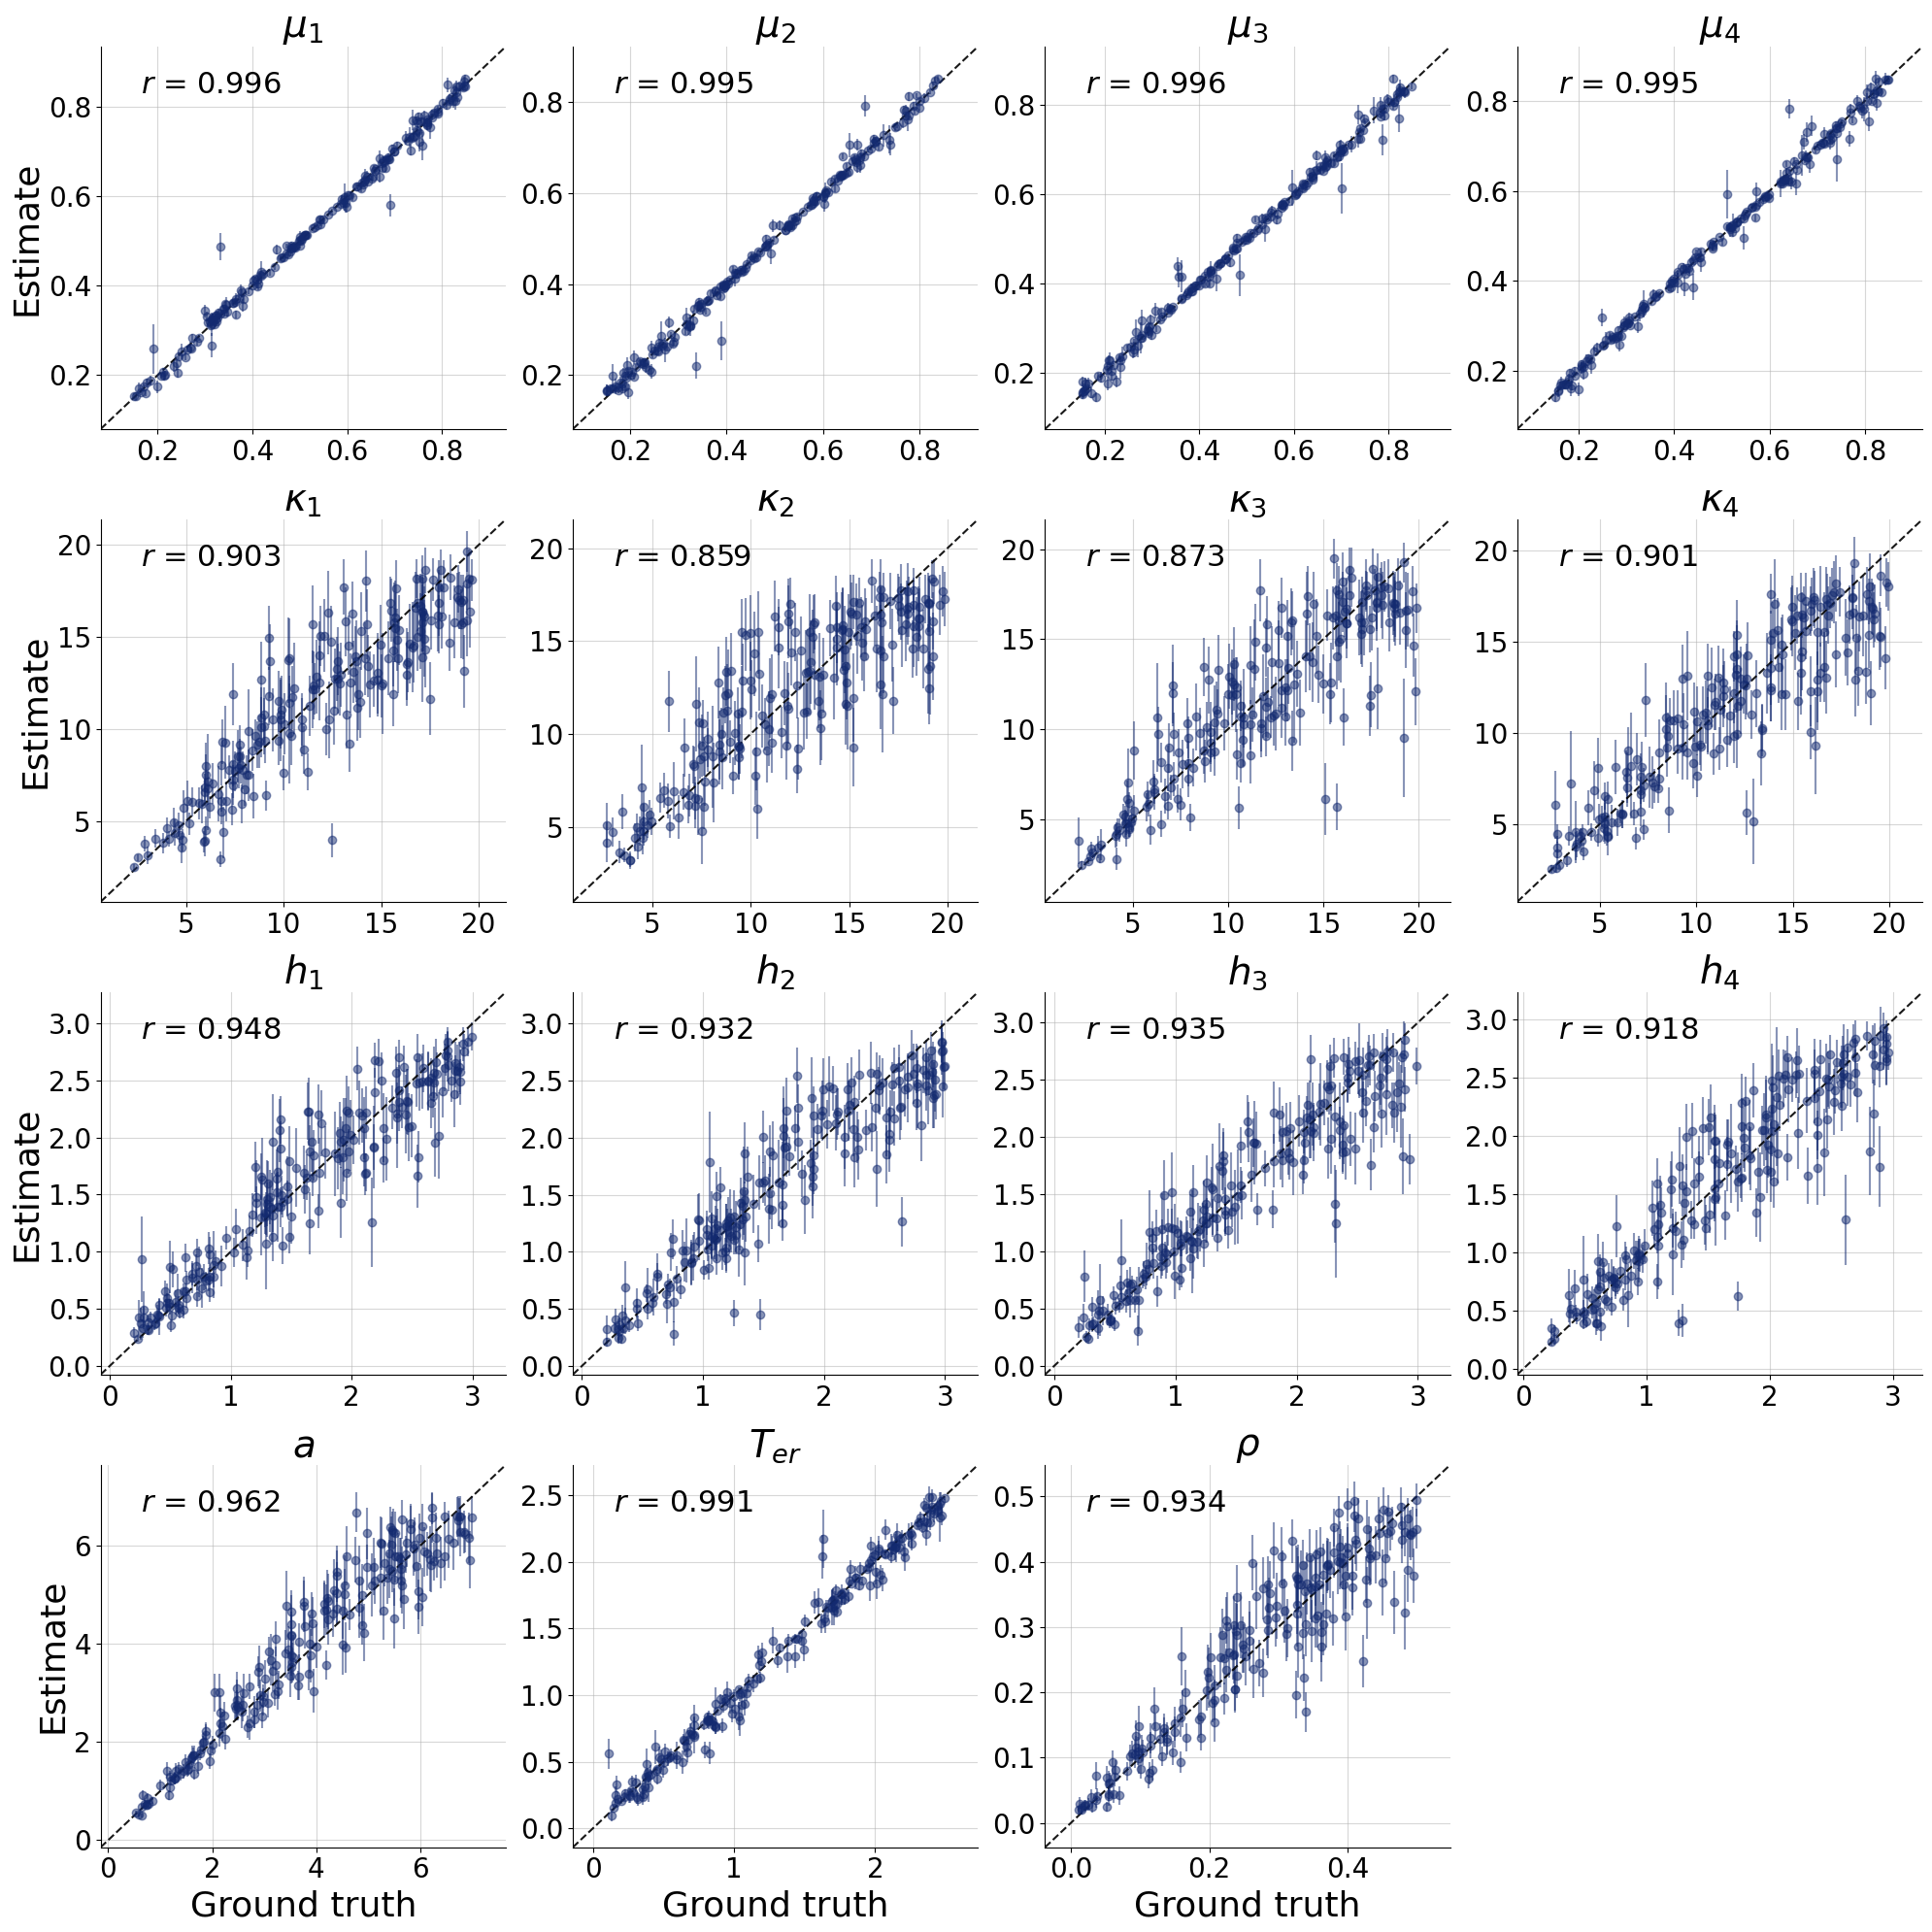

In [19]:
variable_names = [r'$\mu_1$', r'$\mu_2$', r'$\mu_3$', r'$\mu_4$', 
                  r'$\kappa_1$', r'$\kappa_2$', r'$\kappa_3$', r'$\kappa_4$',
                  r'$h_1$', r'$h_2$', r'$h_3$', r'$h_4$',
                  r'$a$', r'$T_{er}$', r'$\rho$']

f = bf.diagnostics.plots.recovery(
    estimates=post_draws, 
    targets=val_sims,
    variable_names = variable_names,
    title_fontsize = 28,
    label_fontsize = 26,
    num_col = 4,
    metric_fontsize = 22,
    tick_fontsize = 20
)


f.savefig('../plots/bddm_recovery.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')

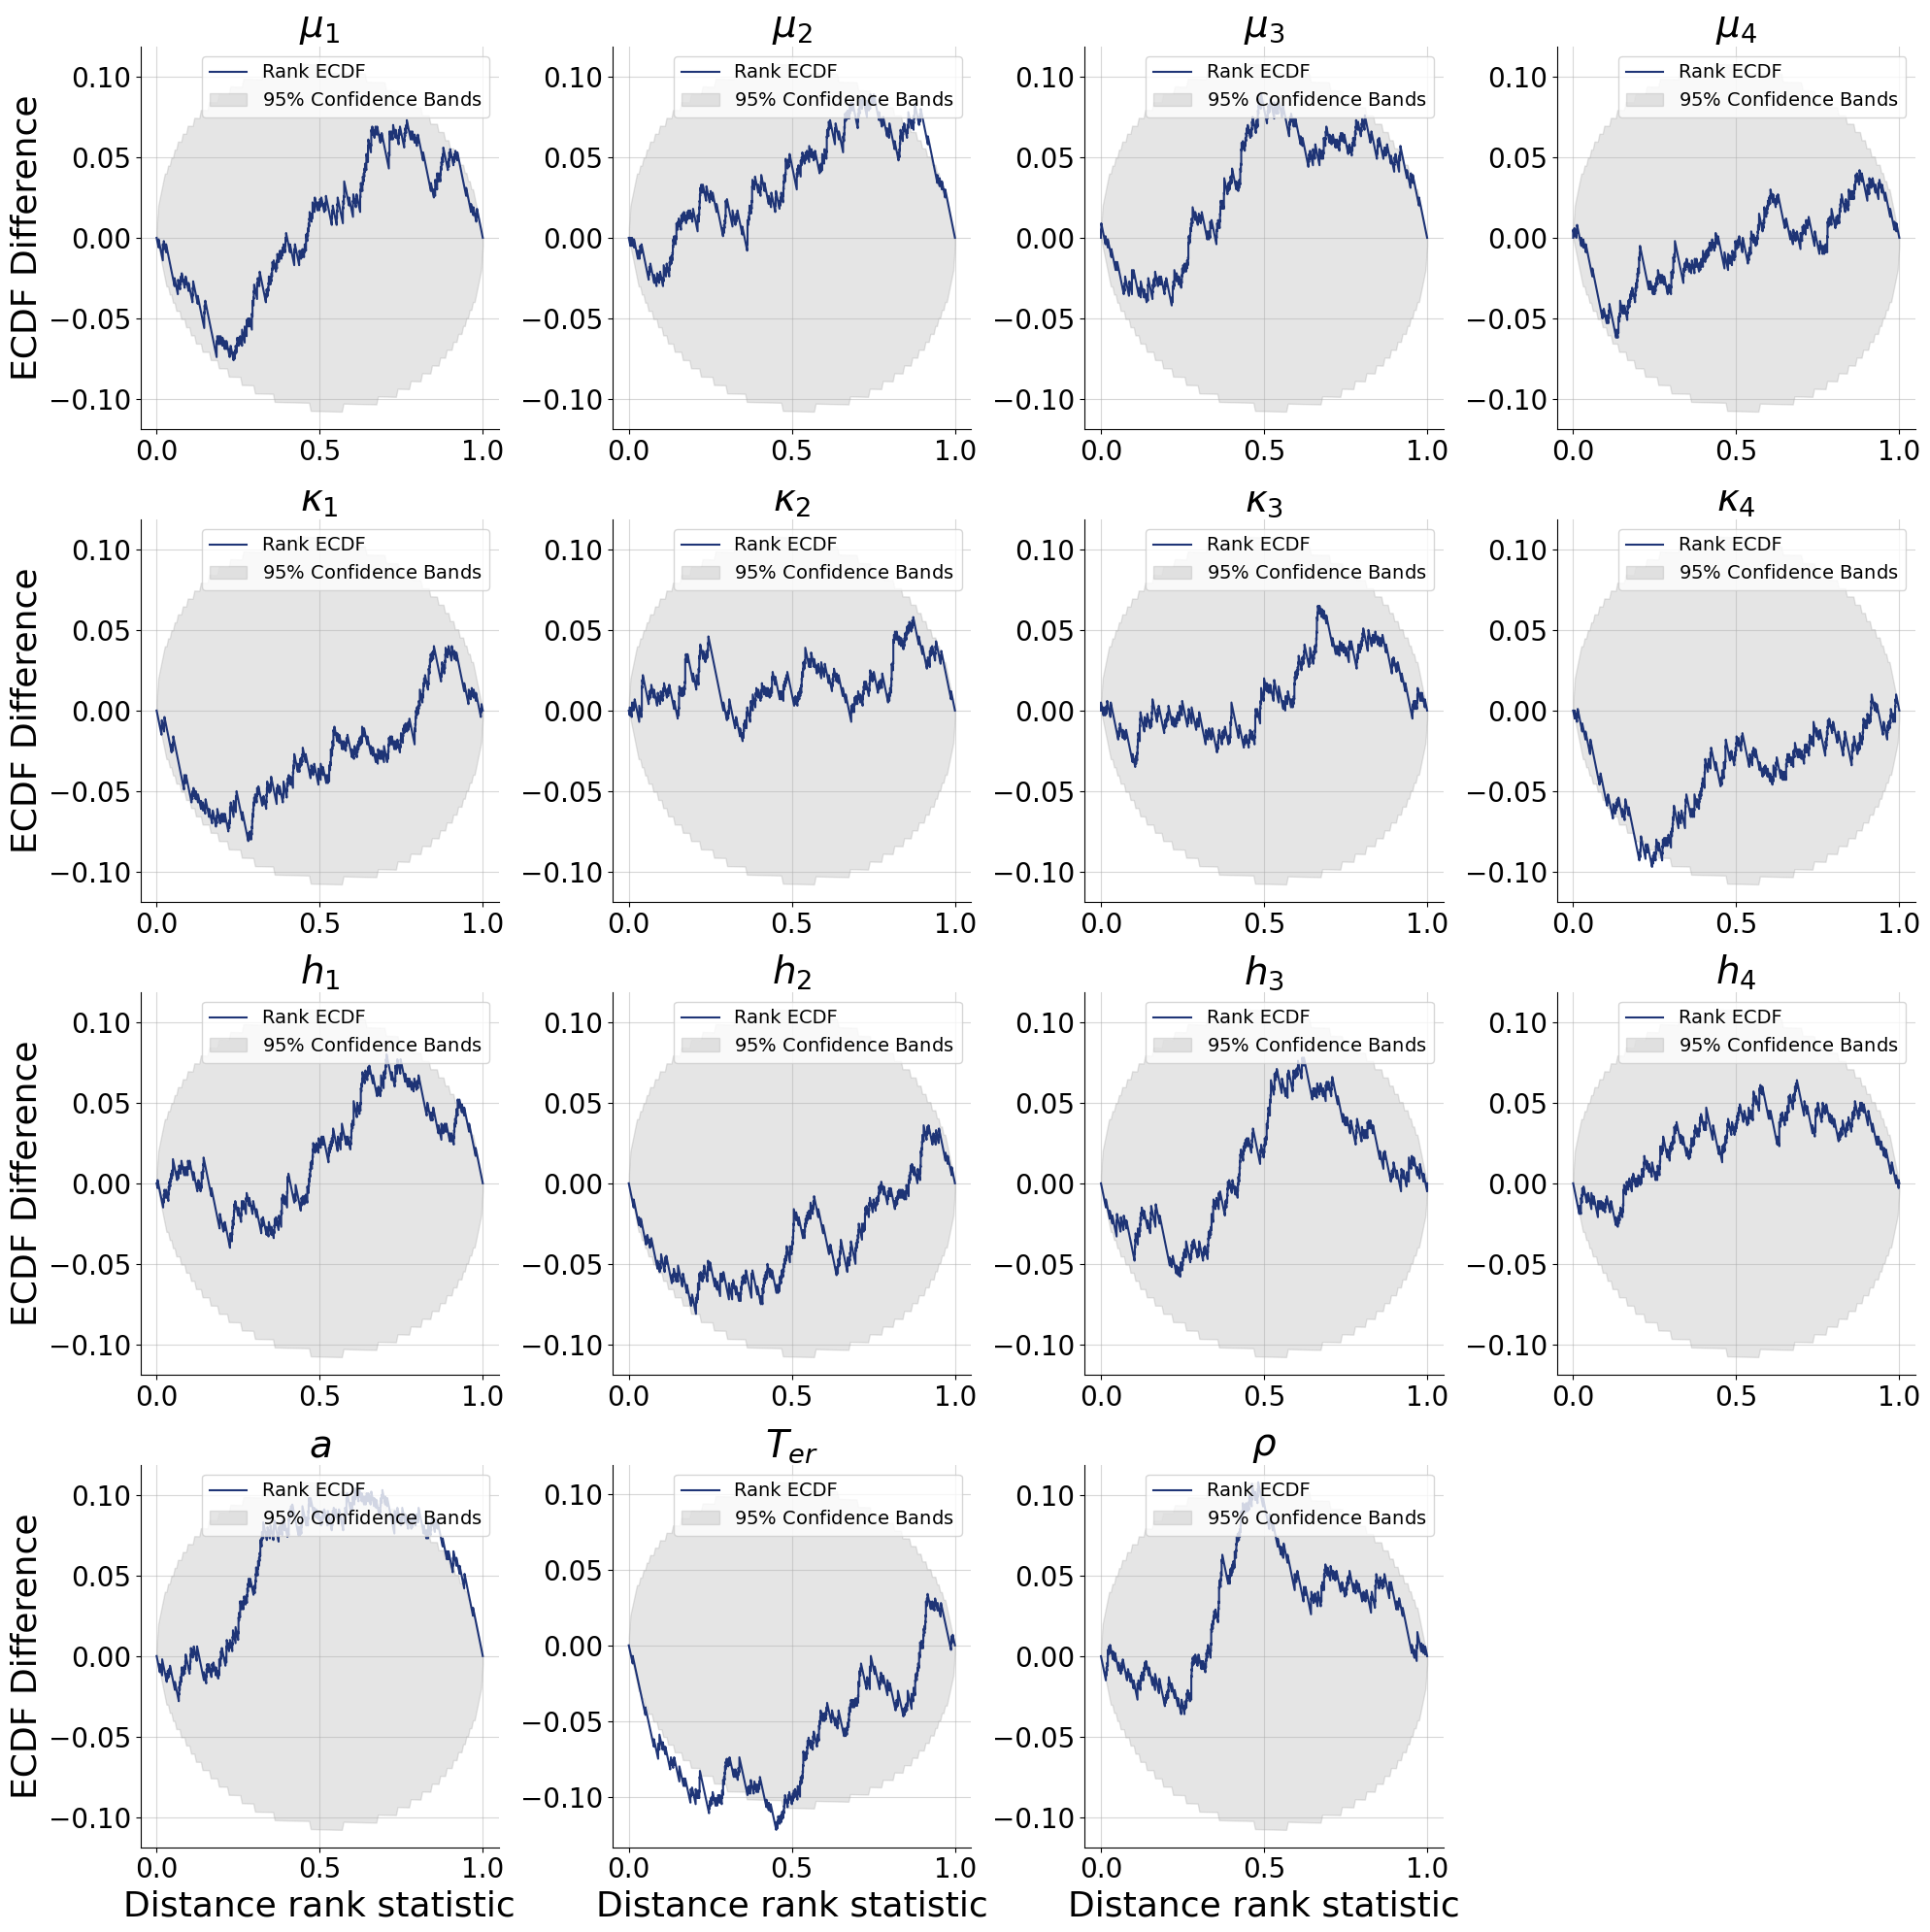

In [20]:
f = bf.diagnostics.plots.calibration_ecdf(
    estimates=post_draws, 
    targets=val_sims,
    difference = True,
    rank_type="distance",
    variable_names = variable_names,
    title_fontsize = 28,
    label_fontsize = 26,
    num_col = 4,
    metric_fontsize = 22,
    tick_fontsize = 20

)

f.savefig('../plots/bddm_ecdf.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')

## data fitting

In [12]:
data = pd.read_table("../notebooks/affect_data_bf.txt", sep = " ")

data["affect"] = math.pi * data["affect"]/100

In [13]:
def data_organize(data):    
    grouped = data.groupby("participant")[["rt", "affect"]].agg(list)
    grouped_outcomes = data.groupby("participant")["outcome"].agg(list)
    outcome_values = np.array([-2, -1, 1, 2])
    outcome_to_index = {val: idx for idx, val in enumerate(outcome_values)}
    
    max_obs = 200
    rt_padded = np.zeros((len(grouped), max_obs))
    rt_min = np.zeros(len(grouped))
    resp_padded = np.zeros((len(grouped), max_obs))
    mask = np.zeros((len(grouped), max_obs), dtype=int)
    con = np.zeros((len(grouped), max_obs, 4), dtype=int)

    for i, (participant_id, outcomes) in enumerate(grouped_outcomes.items()):
        num_trials = min(len(outcomes), 200)
        
        # Iterate through the actual trials for the current participant
        for t in range(num_trials):
            outcome_val = outcomes[t]
            
            # Determine the column index for the current outcome
            col_index = outcome_to_index.get(outcome_val)
            
            # Only proceed if the outcome is one of the four expected values
            if col_index is not None:
                # Set the corresponding position in the 3D array to 1
                # (Participant index, Trial index, Outcome index)
                con[i, t, col_index] = 1

    
    for i, (_, row) in enumerate(grouped.iterrows()):
        rt_list = row["rt"]
        resp_list = row["affect"]
        n = min(len(rt_list), max_obs)
        rt_padded[i, :n] = rt_list[:n]
        resp_padded[i, :n] = resp_list[:n]
        rt_min[i] = np.min(row["rt"])
        mask[i, :n] = 1

    data_dict = {}
    data_dict["num_obs_per_condition"] = data.groupby("participant")["outcome"].value_counts().unstack(fill_value=0).to_numpy()
    data_dict["rt"] = rt_padded
    data_dict["resp"] = resp_padded
    data_dict["observed"] = mask
    data_dict["rt_min"] = rt_min.reshape((215,1))
    data_dict["con"] = con
    
    return data_dict
    
    


In [14]:
data_re = data_organize(data)
%time post_draws = workflow.sample(conditions=data_re, num_samples=1000)

CPU times: user 1.65 s, sys: 118 ms, total: 1.77 s
Wall time: 2.66 s


In [15]:
mu_mean = [np.mean(post_draws["mu"], axis=1)[:,i] for i in range(4)]
var_mean = [np.mean(post_draws["var"], axis=1)[:,i] for i in range(4)]
h_mean = [np.mean(post_draws["h"], axis=1)[:,i] for i in range(4)]
a_mean = np.mean(post_draws["a"], axis = 1)

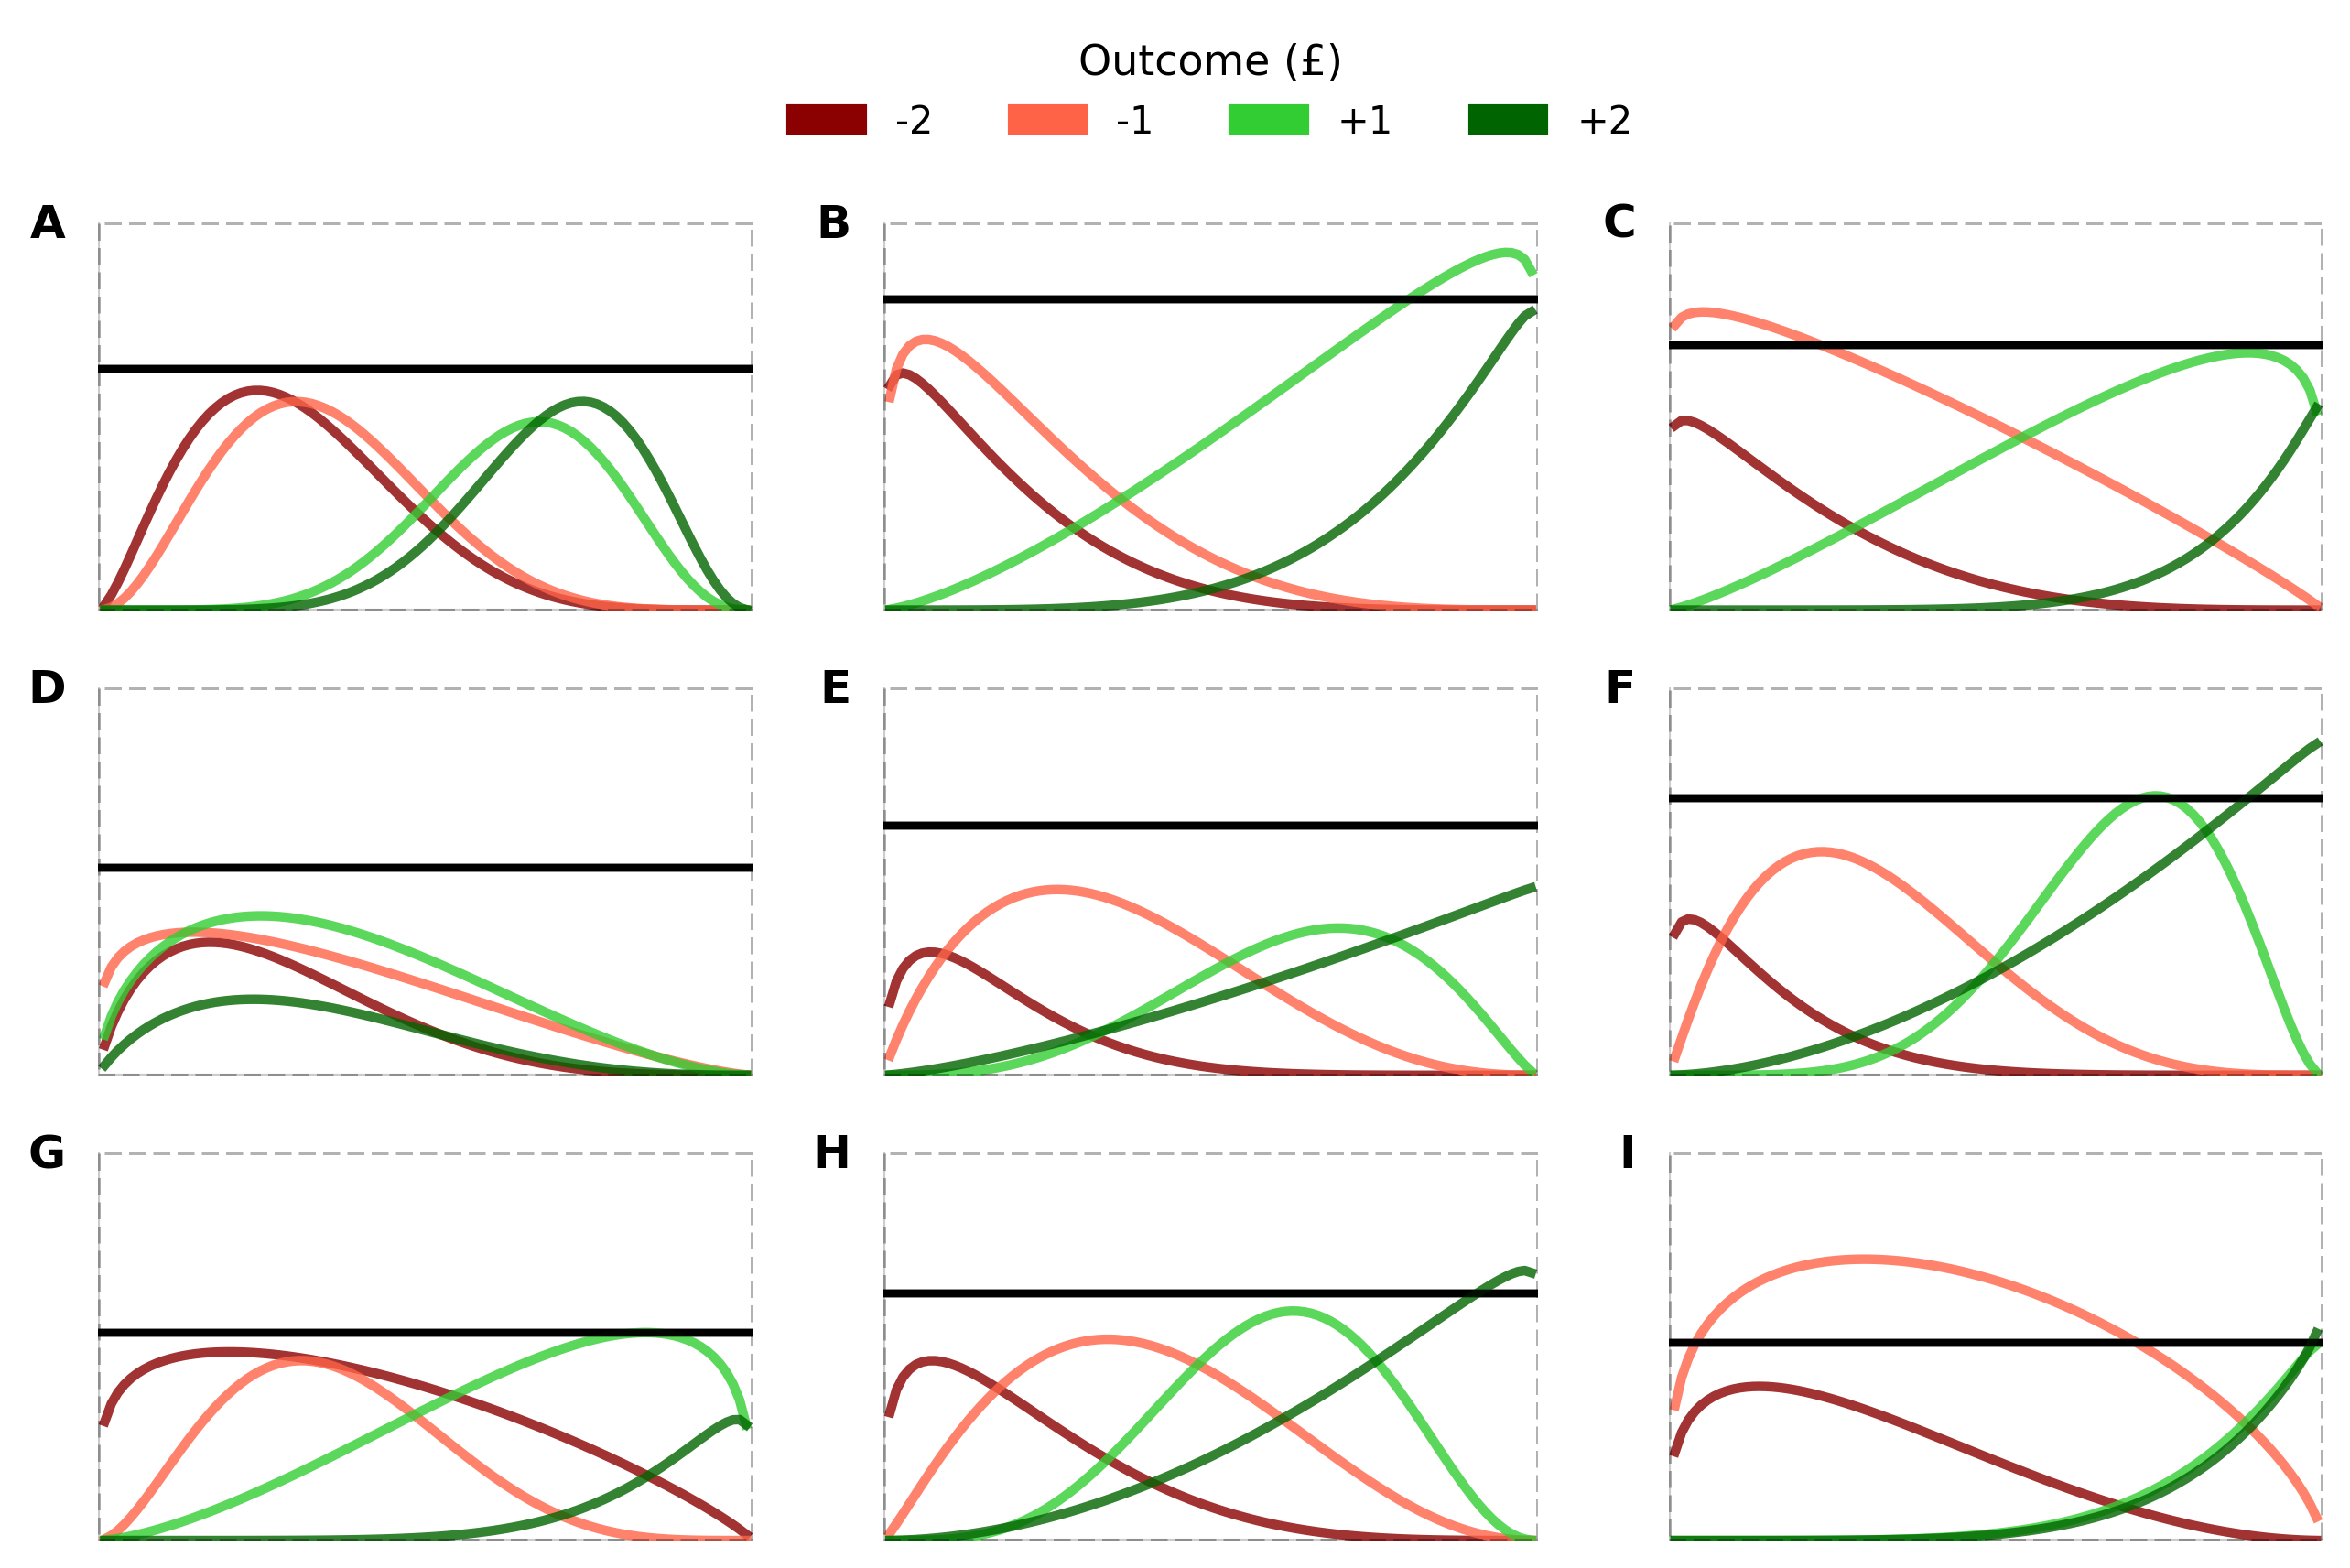

In [16]:
from matplotlib.patches import Rectangle
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['lines.linewidth'] = 2

# Create figure with higher DPI for better quality
fig, ax = plt.subplots(3, 3, figsize=(9, 6), dpi=300)
ax = ax.flatten()

# Define a more professional color palette
# Consider colorblind-friendly options
colors = ['#8B0000', '#FF6347', '#32CD32', '#006400']  # or use plt.cm.Set2.colors
x = np.linspace(0.01, 0.99, 100)
for i in range(1,10):    
    for j in range(4):
        ax[i-1].plot(x, h_mean[j][i] * beta.pdf(x, mu_mean[j][i] * var_mean[j][i], var_mean[j][i] - mu_mean[j][i] * var_mean[j][i]),
                lw = 2.5, color = colors[j], alpha=0.8)
        ax[i-1].hlines(a_mean[i], xmin = 0, xmax = 1, alpha = 0.8, lw=2, color = "black")
    
    # Lighter, thinner reference lines
    ax[i-1].axhline(0, color='#CCCCCC', linewidth=1, ls='-', zorder=0)
    ax[i-1].axvline(0, color='#CCCCCC', linewidth=1, ls='-', zorder=0)
    
    ax[i-1].set_xlim(0, 1)
    ax[i-1].set_ylim(0, 4.5)
    ax[i-1].axis('off')

    # === Add square border around each subplot ===
    rect = Rectangle(
        (0, 0), 1, 1,                # position and size in axes coordinates
        transform=ax[i-1].transAxes,   # use axes coordinates (0–1)
        linewidth=1.2,
        edgecolor='black',
        facecolor='none',
        zorder=10,
        ls="--",
        alpha = 0.3
    )
    ax[i-1].add_patch(rect)
    
# Tighter layout
plt.subplots_adjust(wspace=0.2, hspace=0.2, top=0.85, bottom=0.05, left=0.05, right=0.95)

# Optional: Add panel labels (A, B, C, etc.)
for i, axis in enumerate(ax):
    axis.text(-0.05, 1.05, chr(65+i), transform=axis.transAxes,
              fontsize=12, fontweight='bold', va='top', ha='right')

labels = ['-2', '-1', '+1', '+2']

# Create custom legend handles
from matplotlib.patches import Patch
handles = [Patch(color=colors[j % len(colors)], label=labels[j]) for j in range(4)]

# Place the legend outside the grid
fig.legend(handles=handles, 
           title='Outcome (£)',
           loc='upper center',        # position below all subplots
           bbox_to_anchor=(0.5, 0.98),
           ncol=4,                    # put all labels in one row
           frameon=False,             # remove legend box border
           fontsize=10,
           title_fontsize=11)

# Save in multiple formats
plt.savefig('../plots/scdm.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

## Correlation between parameter and summary statistics

In [22]:
mean_resp = np.zeros((215, 4))
var_resp  = np.zeros((215, 4))
mean_rt   = np.zeros((215, 4))
var_rt    = np.zeros((215, 4))

for n in range(215):
    for c in range(4):
        idx = data_re["con"][n, :, c] == 1

        resp_vals = data_re["resp"][n, idx]
        rt_vals   = data_re["rt"][n, idx]

        mean_resp[n, c] = np.mean(resp_vals)
        var_resp[n, c]  = np.var(resp_vals)

        mean_rt[n, c] = np.mean(rt_vals)
        var_rt[n, c]  = np.var(rt_vals)
a_repeat = np.repeat(np.mean(post_draws["a"], axis=1), 4, axis = 1)
rho_repeat = np.repeat(np.mean(post_draws["r"], axis=1), 4, axis = 1)
Ter_repeat = np.repeat(np.mean(post_draws["ndt"], axis=1), 4, axis = 1)

In [23]:
mu_posmean = np.mean(post_draws["mu"], axis=1)
var_posmean = np.mean(post_draws["var"], axis=1)
h_posmean = np.mean(post_draws["h"], axis=1)
height_drift = np.zeros((215, 4))
mode_drift = np.zeros((215, 4))
IQR_drift = np.zeros((215, 4))


for i in range(215):
    for c in range(4):
        height_drift[i,c] = np.max(h_posmean[i,c] * beta.pdf(x, mu_posmean[i,c] * var_posmean[i,c], var_posmean[i,c] - mu_posmean[i,c] * var_posmean[i,c]))
        Q1 = beta.ppf(0.25, mu_posmean[i,c] * var_posmean[i,c], var_posmean[i,c] - mu_posmean[i,c] * var_posmean[i,c])
        Q3 = beta.ppf(0.75, mu_posmean[i,c] * var_posmean[i,c], var_posmean[i,c] - mu_posmean[i,c] * var_posmean[i,c])
        IQR_drift[i,c] = Q3- Q1
        mode_drift[i,c] = (mu_posmean[i,c] * var_posmean[i,c] - 1)/(var_posmean[i,c] - 2)

height_drift_a_ratio = height_drift/a_repeat

### Mean RT

In [24]:
ndt = np.tile(np.mean(post_draws["ndt"], axis=1), (1,4))
mean_rt = mean_rt - ndt

In [25]:
def dict_cor(target):
    predictors = {
        "h": h_posmean.flatten(),
        "mu": mu_posmean.flatten(),
        "kappa": var_posmean.flatten(),
        "height": height_drift.flatten(),
        "mode": mode_drift.flatten(),
        "IQR": IQR_drift.flatten(),
        "a": a_repeat.flatten(),
        "rho": rho_repeat.flatten(),
        "Ter": Ter_repeat.flatten(),
        "drift_a_ratio": height_drift_a_ratio.flatten(),
    }
    
    corrs = {
        name: np.round(np.corrcoef(target.flatten(), values)[0, 1], 3)
        for name, values in predictors.items()
    }
    return corrs

In [26]:
dict_cor(mean_rt)

{'h': -0.207,
 'mu': -0.02,
 'kappa': -0.069,
 'height': -0.34,
 'mode': -0.019,
 'IQR': 0.057,
 'a': 0.644,
 'rho': 0.038,
 'Ter': -0.02,
 'drift_a_ratio': -0.689}

In [27]:
dict_cor(var_rt)

{'h': -0.331,
 'mu': 0.002,
 'kappa': -0.001,
 'height': -0.519,
 'mode': 0.007,
 'IQR': 0.013,
 'a': 0.064,
 'rho': 0.019,
 'Ter': -0.157,
 'drift_a_ratio': -0.502}

In [28]:
dict_cor(mean_resp)

{'h': -0.145,
 'mu': 0.987,
 'kappa': 0.051,
 'height': -0.021,
 'mode': 0.992,
 'IQR': -0.113,
 'a': 0.027,
 'rho': 0.003,
 'Ter': -0.015,
 'drift_a_ratio': -0.038}

In [29]:
dict_cor(var_resp)

{'h': 0.001,
 'mu': -0.123,
 'kappa': -0.295,
 'height': -0.429,
 'mode': -0.099,
 'IQR': 0.513,
 'a': -0.392,
 'rho': 0.044,
 'Ter': 0.087,
 'drift_a_ratio': -0.158}

## Correlation between parameters and summary statistics visualization

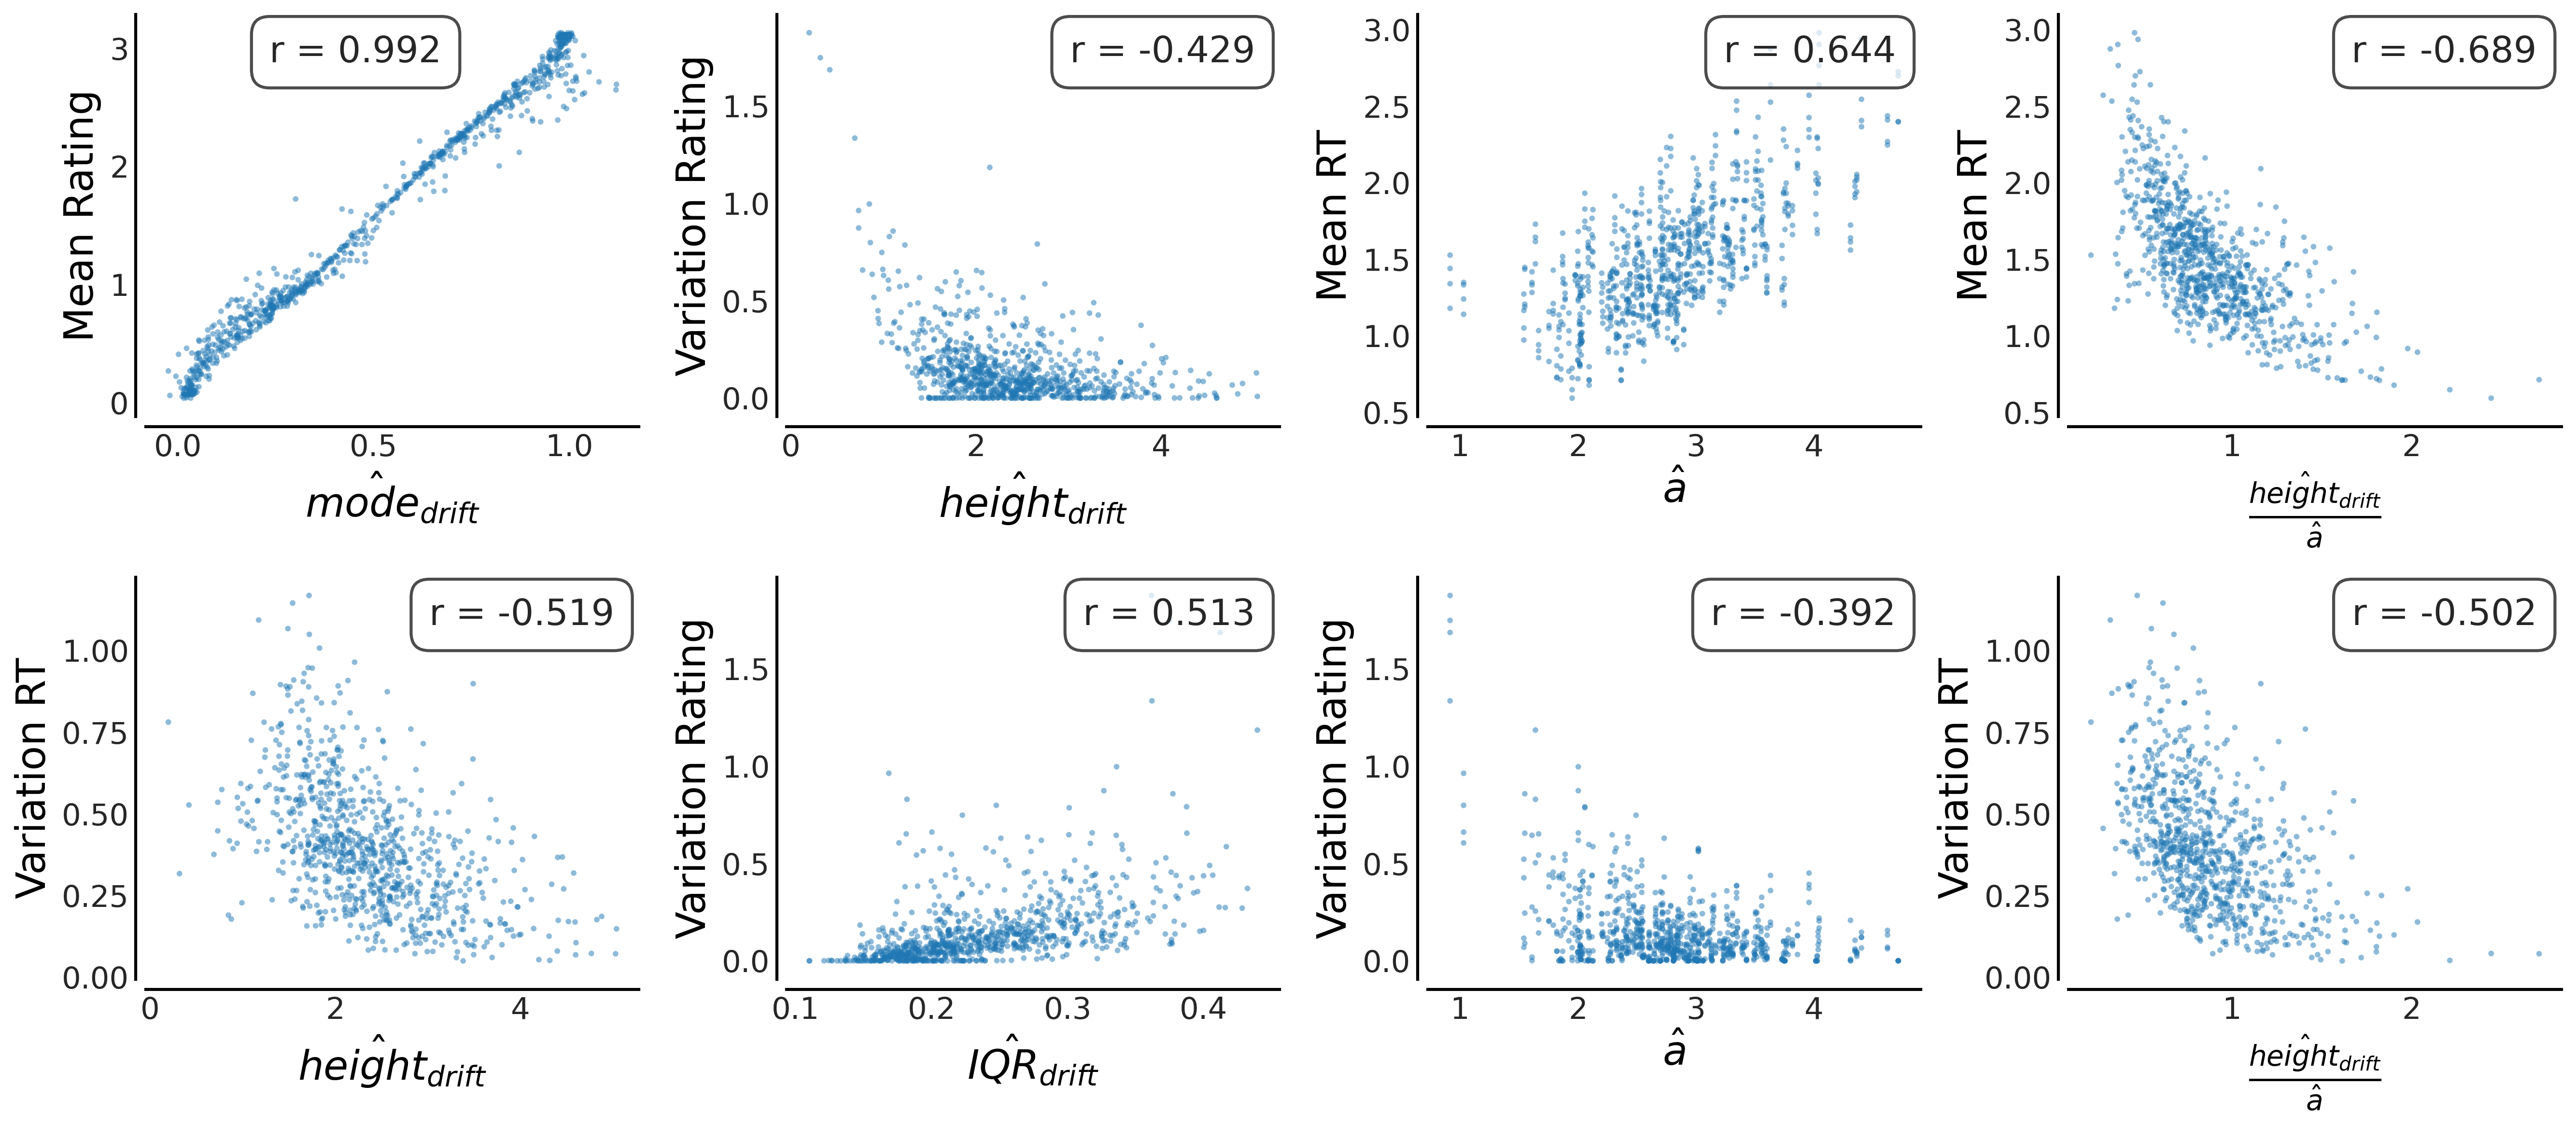

In [30]:
fig, ax = plt.subplots(2, 4, figsize=(18, 8), dpi=300)
plt.style.use("seaborn-v0_8-white")

# Common style
marker_kws = dict(s=8, alpha=0.5, edgecolors='none')
BBOX_PROPS = dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.7, edgecolor='black', linewidth=1.5)
CORR_TEXT_KWS = dict( horizontalalignment='right', verticalalignment='top')

#ax[0, 0].scatter(np.mean(post_draws["mu"], axis=1).flatten(),mean_resp.flatten(), **marker_kws)
ax[0, 0].scatter(mode_drift.flatten(),mean_resp.flatten(), **marker_kws)
ax[0, 0].set_ylabel("Mean Rating", fontsize=20)
ax[0, 0].set_xlabel(r'$\hat{mode}_{drift}$', fontsize=20)
ax[0, 0].text(0.6, 0.95,f'r = {np.corrcoef(mean_resp.flatten(),mode_drift.flatten())[1,0]:.3f}', size = 18, bbox=BBOX_PROPS, transform=ax[0, 0].transAxes, **CORR_TEXT_KWS)


ax[1, 0].scatter(height_drift.flatten(), var_rt.flatten(), **marker_kws)
ax[1, 0].set_ylabel("Variation RT", fontsize=20)
ax[1, 0].set_xlabel(r'$\hat{height}_{drift}$', fontsize=20)
ax[1, 0].text(0.95, 0.95,f'r = {np.corrcoef(var_rt.flatten(),height_drift.flatten())[1,0]:.3f}', size = 18, bbox=BBOX_PROPS, transform=ax[1, 0].transAxes, **CORR_TEXT_KWS)


ax[0, 1].scatter(height_drift.flatten(), var_resp.flatten(), **marker_kws)
ax[0, 1].set_ylabel("Variation Rating", fontsize=20)
ax[0, 1].set_xlabel(r'$\hat{height}_{drift}$', fontsize=20)
ax[0, 1].text(0.95, 0.95,f'r = {np.corrcoef(var_resp.flatten(),height_drift.flatten())[1,0]:.3f}', size = 18, bbox=BBOX_PROPS, transform=ax[0, 1].transAxes, **CORR_TEXT_KWS)


ax[1, 1].scatter(IQR_drift.flatten(), var_resp.flatten(), **marker_kws)
ax[1, 1].set_ylabel("Variation Rating", fontsize=20)
ax[1, 1].set_xlabel(r'$\hat{IQR}_{drift}$', fontsize=20)
ax[1, 1].text(0.95, 0.95, f'r = {np.corrcoef(var_resp.flatten(),IQR_drift.flatten())[1,0]:.3f}', size = 18, bbox=BBOX_PROPS, transform=ax[1, 1].transAxes, **CORR_TEXT_KWS)


ax[0, 2].scatter(a_repeat.flatten(), mean_rt.flatten(), **marker_kws)
ax[0, 2].set_ylabel("Mean RT", fontsize=20)
ax[0, 2].set_xlabel(r'$\hat{a}$', fontsize=20)
ax[0, 2].text(0.95, 0.95,f'r = {np.corrcoef(mean_rt.flatten(),a_repeat.flatten())[1,0]:.3f}', size = 18, bbox=BBOX_PROPS, transform=ax[0, 2].transAxes, **CORR_TEXT_KWS)

ax[1, 2].scatter(a_repeat.flatten(), var_resp.flatten(), **marker_kws)
ax[1, 2].set_ylabel("Variation Rating", fontsize=20)
ax[1, 2].set_xlabel(r'$\hat{a}$', fontsize=20)
ax[1, 2].text(0.95, 0.95,f'r = {np.corrcoef(var_resp.flatten(),a_repeat.flatten())[1,0]:.3f}', size = 18, bbox=BBOX_PROPS, transform=ax[1, 2].transAxes, **CORR_TEXT_KWS)


ax[0, 3].scatter(height_drift_a_ratio.flatten(), mean_rt.flatten(), **marker_kws)
ax[0, 3].set_ylabel("Mean RT", fontsize=20)
ax[0, 3].set_xlabel(r'$\frac{\hat{height}_{drift}}{\hat{a}}$', fontsize=20)
ax[0, 3].text(0.95, 0.95,f'r = {np.corrcoef(mean_rt.flatten(),height_drift_a_ratio.flatten())[1,0]:.3f}', size = 18, bbox=BBOX_PROPS, transform=ax[0, 3].transAxes, **CORR_TEXT_KWS)


ax[1, 3].scatter(height_drift_a_ratio.flatten(), var_rt.flatten(), **marker_kws)
ax[1, 3].set_ylabel("Variation RT", fontsize=20)
ax[1, 3].set_xlabel(r'$\frac{\hat{height}_{drift}}{\hat{a}}$', fontsize=20)
ax[1, 3].text(0.95, 0.95,f'r = {np.corrcoef(var_rt.flatten(),height_drift_a_ratio.flatten())[1,0]:.3f}', size = 18, bbox=BBOX_PROPS, transform=ax[1, 3].transAxes, **CORR_TEXT_KWS)



# Polish axes
for a in ax.flatten():
    a.tick_params(labelsize=15)
    sns.despine(ax=a, offset=5)  # clean up top/right borders

plt.tight_layout(pad=1.5)
plt.subplots_adjust(wspace=0.3, hspace=0.4)

for ax in fig.axes:
    if not ax.has_data():
        ax.remove()
plt.savefig('../plots/bddm_correlation.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()


In [31]:
bddm_estimates = {}
for key in post_draws.keys():
    bddm_estimates[key] = np.mean(post_draws[key], axis = 1)
bddm_estimates["height_drift"] = height_drift
bddm_estimates["height_drift_a_ratio"] = height_drift_a_ratio
bddm_estimates["mode_drift"] = mode_drift
bddm_estimates["IQR_drift"] = IQR_drift

%store bddm_estimates

Stored 'bddm_estimates' (dict)


## Posterior predictive distribution

In [17]:
def ppc(batch_info):
    theta = prior                # batched
    batch_size = theta["r"].shape[0]
    num_obs_per_condition = np.random.randint(min_obs_per_condition, max_obs_per_condition, size = 4)
    simulated_data = cuda_simulator(**theta, num_obs_per_condition = num_obs_per_condition, rng=RNG)  # batched model
    return {
    "num_obs_per_condition": np.tile(num_obs_per_condition, [batch_size,1]),   # give it a key!
    **theta,
    **simulated_data
    }

In [18]:
post_draws = workflow.sample(conditions=data_re, num_samples=2000)

prior = {}
n_replicates = 100
mean_rt_ppc = np.zeros((n_replicates, 215,4))
std_rt_ppc = np.zeros((n_replicates, 215,4))
mean_resp_ppc = np.zeros((n_replicates, 215,4))
std_resp_ppc = np.zeros((n_replicates, 215,4))

quantiles_rt_ppc = np.zeros((n_replicates, 215,4, 5))
quantiles_resp_ppc = np.zeros((n_replicates, 215,4, 5))
quantile = [0.1, 0.3, 0.5, 0.7, 0.9]


for i in range(n_replicates):
    for key in post_draws.keys():
        idx = np.random.randint(0, post_draws[key].shape[1], size=post_draws[key].shape[0])
        prior[key] = post_draws[key][np.arange(post_draws[key].shape[0]), idx]
    ppc_simulated = ppc(1)
    for n in range(215):
        for c in range(4):
            mean_rt_ppc[i,n,c] = np.mean(data_re["rt"][n,:][data_re["con"][n,:,c] == 1])
            std_rt_ppc[i,n,c] = np.std(data_re["rt"][n,:][data_re["con"][n,:,c] == 1])
    
            mean_resp_ppc[i,n,c] = np.mean(ppc_simulated["rt"][n,:][ppc_simulated["con"][n,:,c] == 1])
            std_resp_ppc[i,n,c] = np.std(ppc_simulated["rt"][n,:][ppc_simulated["con"][n,:,c] == 1])
            for q in range(5):
                quantiles_rt_ppc[i,n,c,q] = np.quantile(ppc_simulated["rt"][n,:][ppc_simulated["con"][n,:,c] == 1], quantile[q])
                quantiles_resp_ppc[i,n,c,q] = np.quantile(ppc_simulated["resp"][n,:][ppc_simulated["con"][n,:,c] == 1], quantile[q])



### Quantiles: 0.1, 0.3, 0.5, 0.7, 0.9

In [19]:
quantiles_rt_obs = np.zeros((215,4, 5))
quantiles_resp_obs = np.zeros((215,4, 5))

quantile = [0.1, 0.3, 0.5, 0.7, 0.9]

for n in range(215):
    for c in range(4):
        for q in range(5):
            #response
            quantiles_rt_obs[n,c,q] = np.quantile(data_re["rt"][n,:][data_re["con"][n,:,c] == 1], quantile[q])
            quantiles_resp_obs[n,c,q] = np.quantile(data_re["resp"][n,:][data_re["con"][n,:,c] == 1], quantile[q])
    


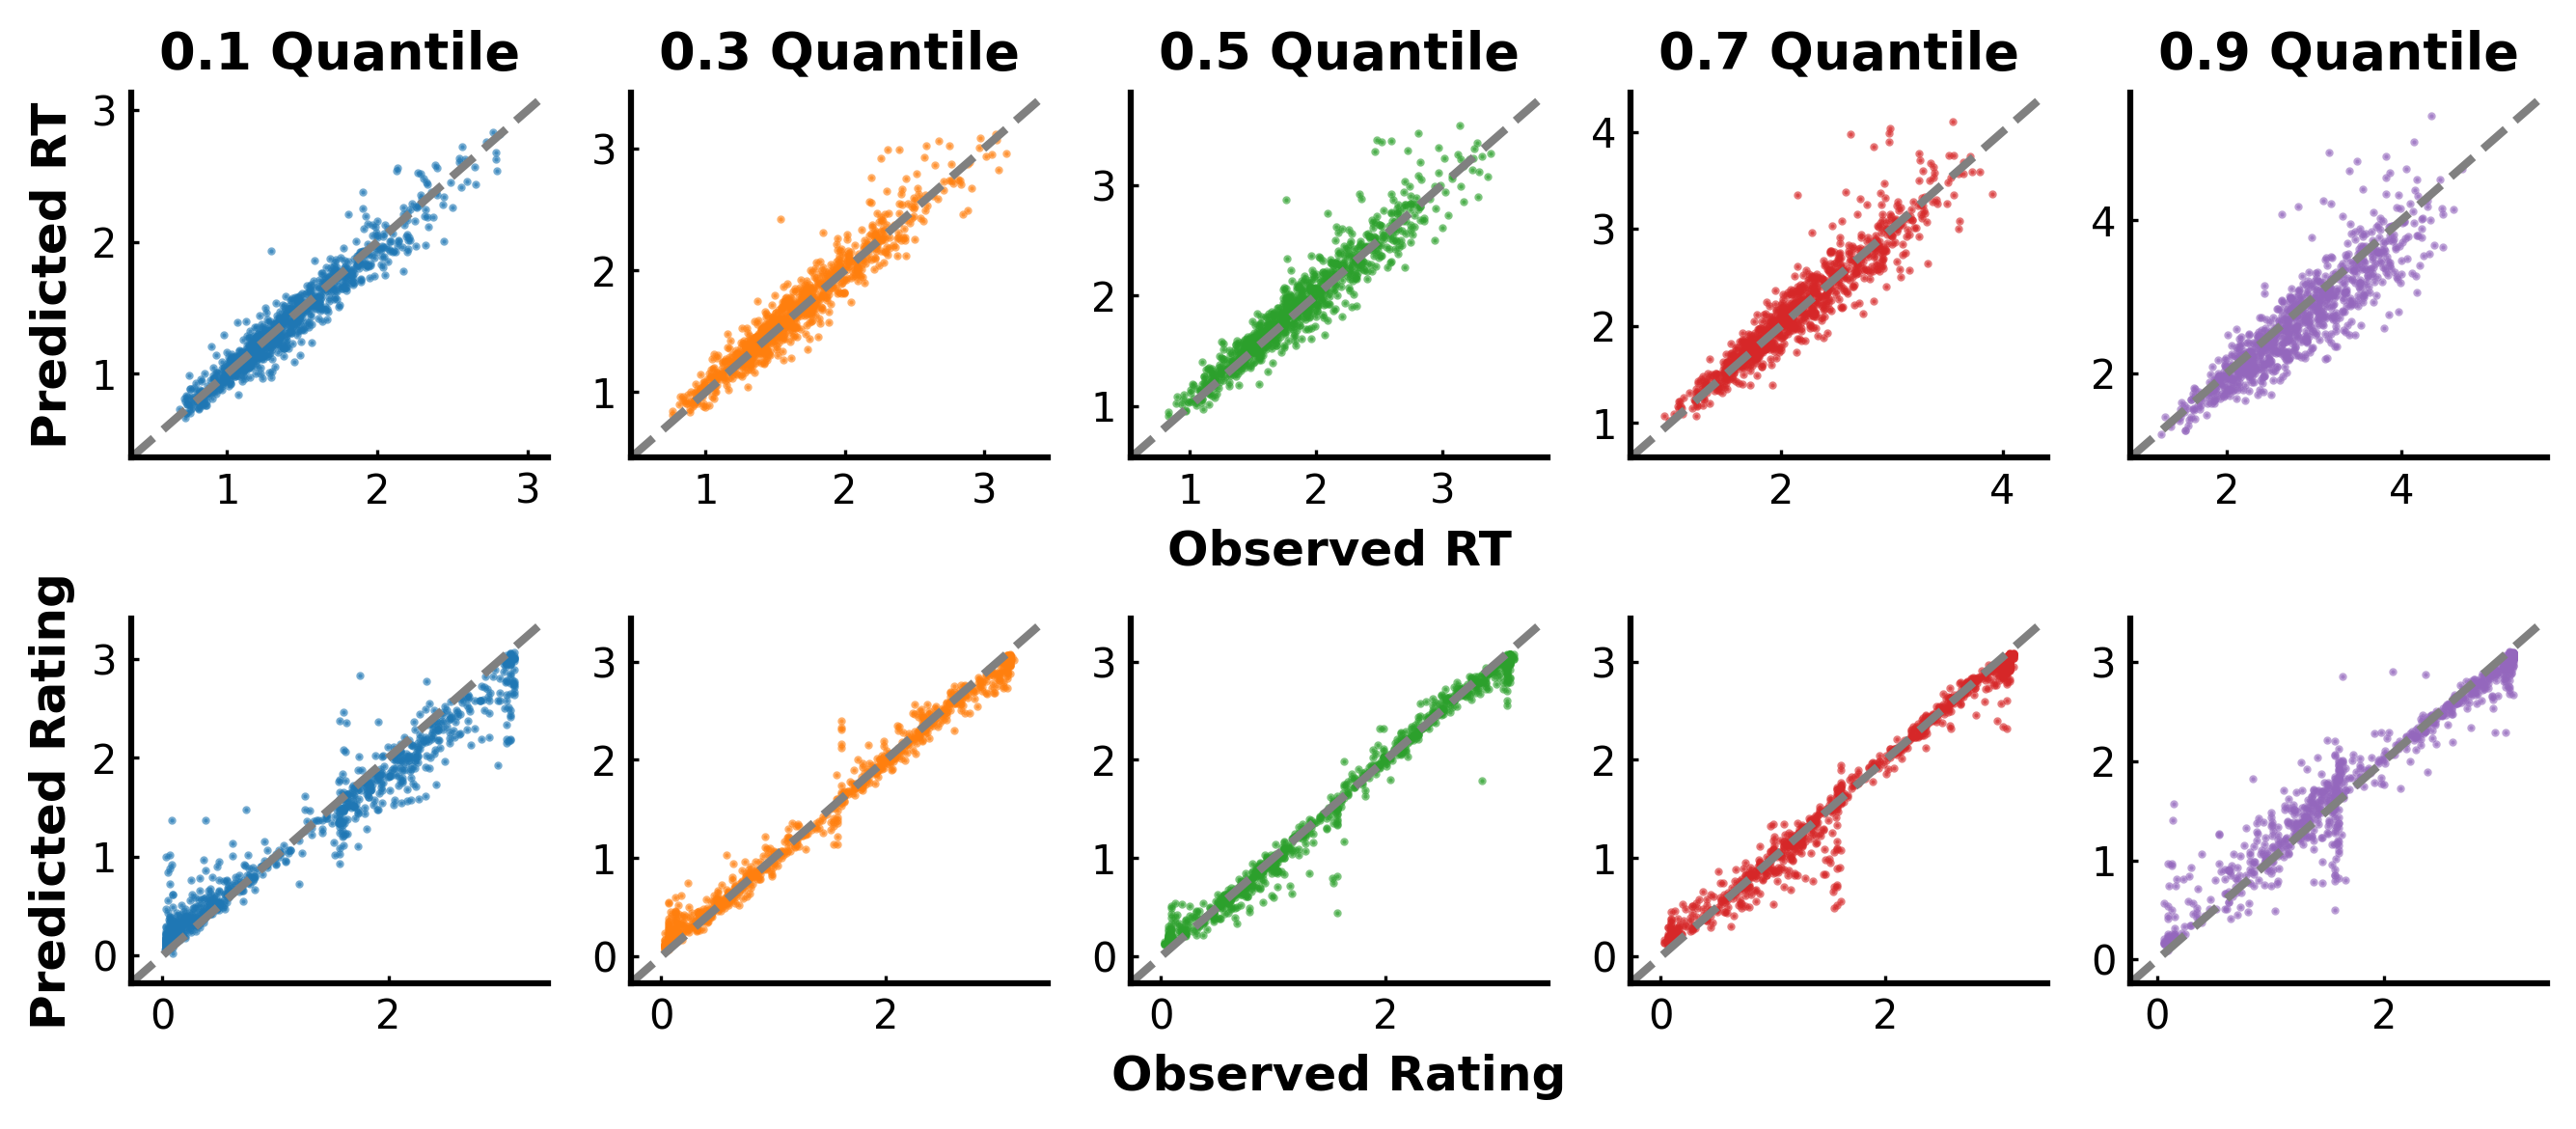

In [20]:
fig, ax = plt.subplots(2, 5, figsize = (9, 4), dpi = 300)
colors = plt.cm.tab10.colors 

for i in range(5):
    quantiles_rt_ppc_mean = np.mean(quantiles_rt_ppc[:,:,:,i], axis = 0)
    ax[0, i].scatter(quantiles_rt_obs[:,:,i], quantiles_rt_ppc_mean,
                    s = 1, alpha = 0.6, color = colors[i])
    ax[0, i].axline((1,1), slope=1, ls = "--", color = "grey")
    ax[0, i].set_title(f"{quantile[i]} Quantile", size = 13, weight = "bold")
    ax[0, i].set_xlim(np.min(np.vstack((quantiles_rt_obs[:,:,i], quantiles_rt_ppc_mean)).flatten()) -0.3, np.max(np.vstack((quantiles_rt_obs[:,:,i], quantiles_rt_ppc_mean)).flatten())+0.3)
    ax[0, i].set_ylim(np.min(np.vstack((quantiles_rt_obs[:,:,i], quantiles_rt_ppc_mean)).flatten()) -0.3, np.max(np.vstack((quantiles_rt_obs[:,:,i], quantiles_rt_ppc_mean)).flatten())+0.3)
    ax[0, 2].set_xlabel("Observed RT", size = 12, weight = "bold")
    ax[0, 0].set_ylabel("Predicted RT", size = 12, weight = "bold")
    
for i in range(5):
    quantiles_resp_ppc_mean = np.mean(quantiles_resp_ppc[:,:,:,i], axis = 0)
    ax[1, i].scatter(quantiles_resp_obs[:,:,i], quantiles_resp_ppc_mean,
                    s = 1, alpha = 0.6, color = colors[i])
    ax[1, i].axline((1,1), slope=1, ls = "--", color = "grey")
    ax[1, i].set_xlim(np.min(np.vstack((quantiles_resp_obs[:,:,i], quantiles_resp_ppc_mean)).flatten()) -0.3, np.max(np.vstack((quantiles_resp_obs[:,:,i], quantiles_resp_ppc_mean)).flatten())+0.3)
    ax[1, i].set_ylim(np.min(np.vstack((quantiles_resp_obs[:,:,i], quantiles_resp_ppc_mean)).flatten()) -0.3, np.max(np.vstack((quantiles_resp_obs[:,:,i], quantiles_resp_ppc_mean)).flatten())+0.3)
    ax[1, 2].set_xlabel("Observed Rating", size = 12, weight = "bold")
    ax[1, 0].set_ylabel("Predicted Rating", size = 12, weight = "bold")

for a in ax.flatten():
    #a.set_aspect("equal", adjustable="box")
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.tick_params(direction="in", length=2)
    
plt.tight_layout()
plt.savefig('../plots/quantile_bddm.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

### Quantify the goodness of fit

In [21]:
quantiles_resp_ppc_mean = np.mean(quantiles_resp_ppc, axis = 0)
gof_resp_bddm = np.mean(np.mean(abs(quantiles_resp_obs - quantiles_resp_ppc_mean), axis = 1), axis = 1)
%store gof_resp_bddm

Stored 'gof_resp_bddm' (ndarray)


In [22]:
quantiles_rt_ppc_mean = np.mean(quantiles_rt_ppc, axis = 0)
gof_rt_bddm = np.mean(np.mean(abs(quantiles_rt_obs - quantiles_rt_ppc_mean), axis = 1), axis = 1)
%store gof_rt_bddm

Stored 'gof_rt_bddm' (ndarray)


### Problematic prediction based on ratings

problem 1 is the overestimate of 0.1 quantile when the observed 0.1 quantile is close to 0.

In [38]:
quantiles_resp_ppc_mean = np.mean(quantiles_resp_ppc, axis = 0)
problem_participant = np.where((abs(quantiles_resp_obs[:,:,0] - quantiles_resp_ppc_mean[:,:,0]) > 0.8) & (quantiles_resp_obs[:,:,0]<1))[0][:4]
problem_condition = np.where((abs(quantiles_resp_obs[:,:,0] - quantiles_resp_ppc_mean[:,:,0]) > 0.8) & (quantiles_resp_obs[:,:,0]<1))[1][:4]

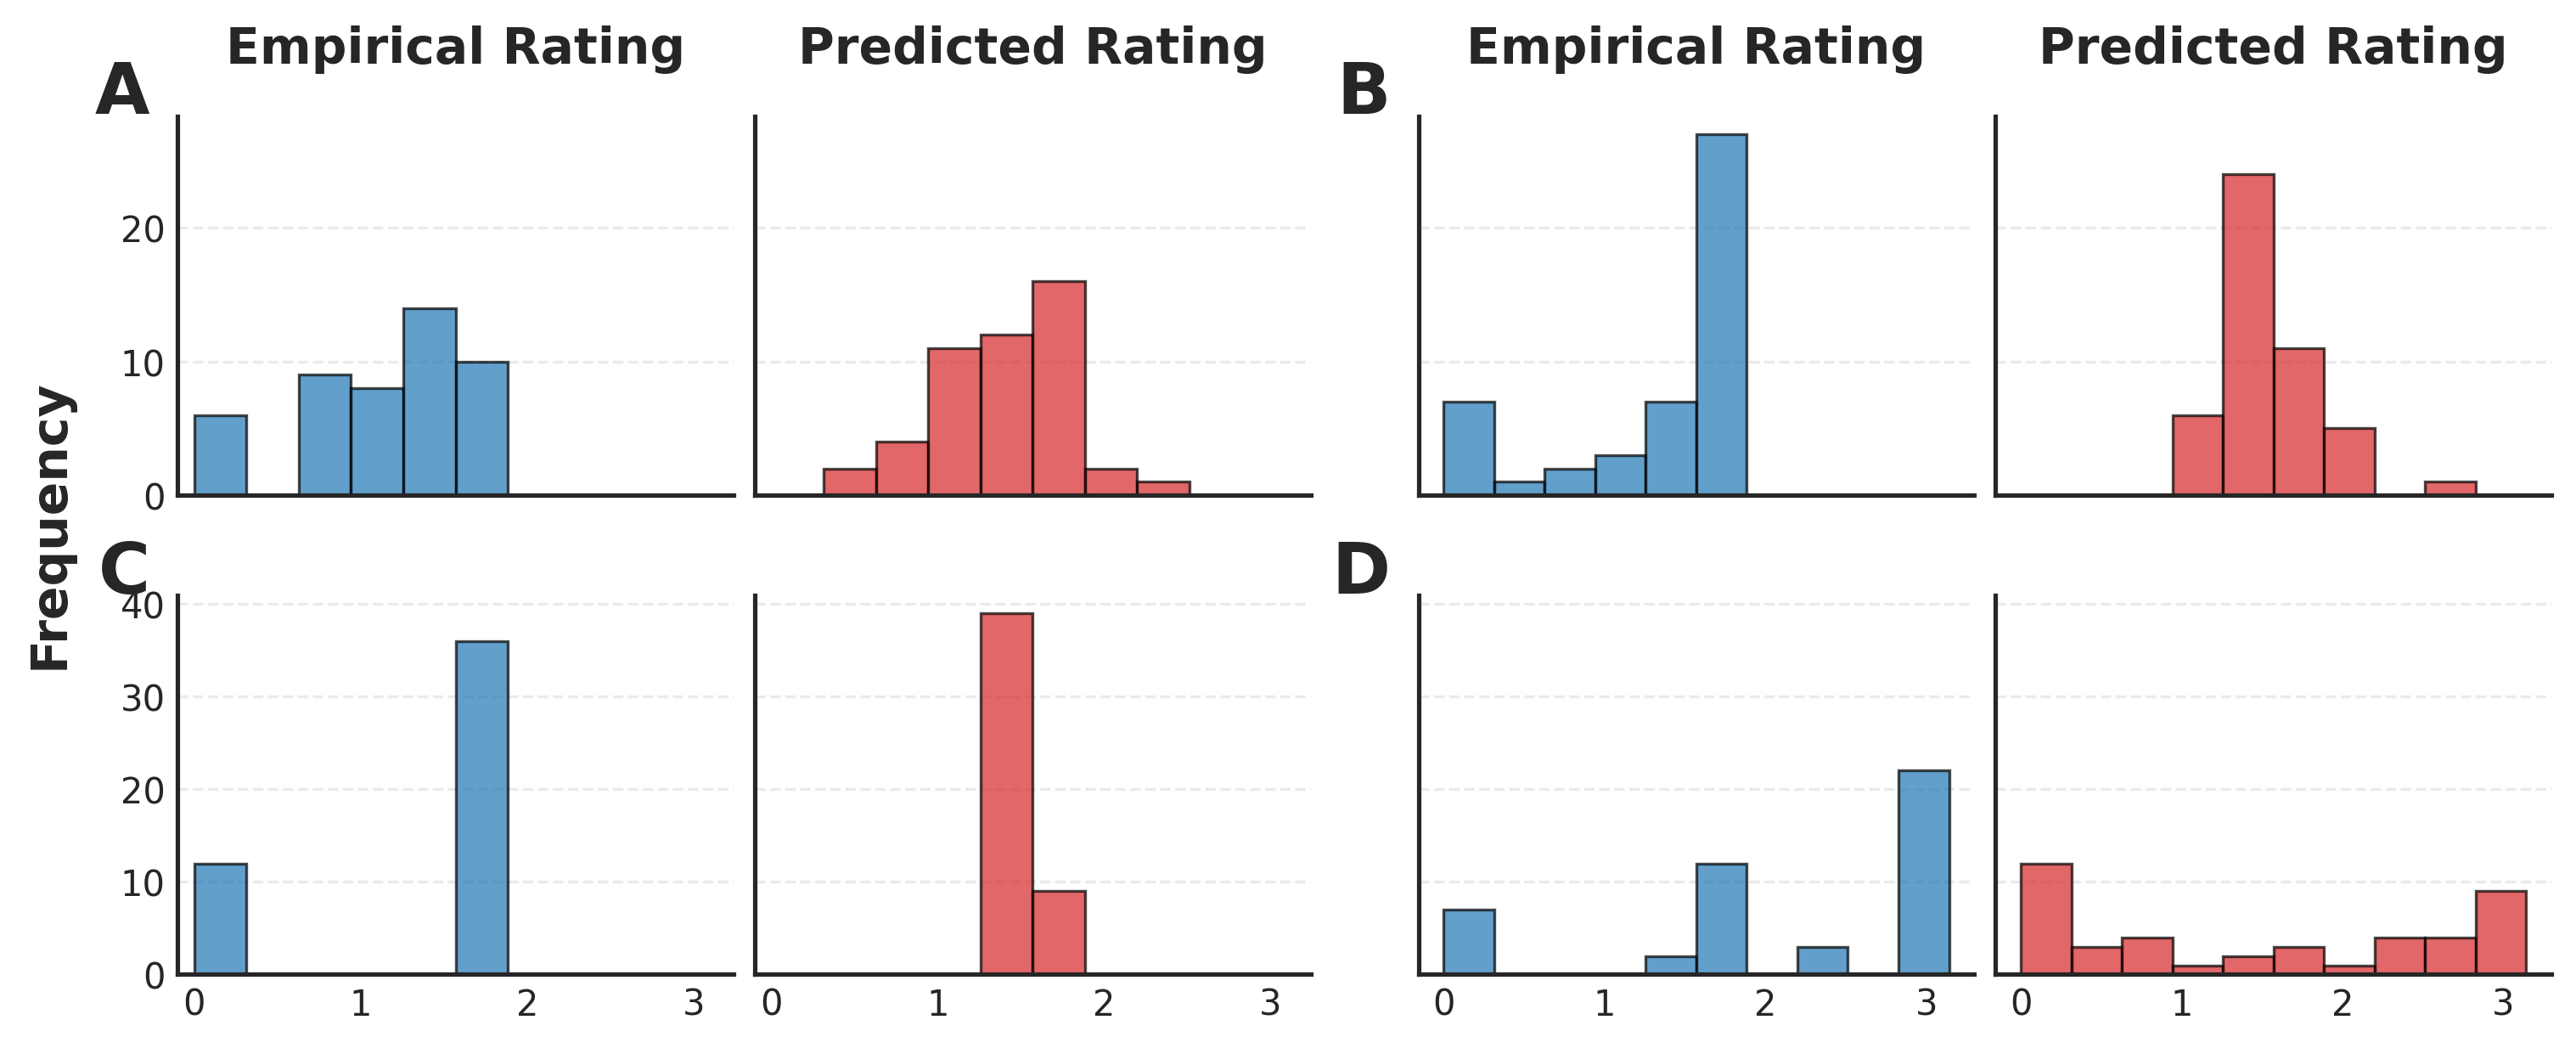

In [40]:
# Define colors and styles
empirical_color = '#1f77b4'  # Muted Blue
predicted_color = '#d62728'  # Muted Red
bin_edges = np.linspace(0, np.pi, 11)  # 10 equal bins across full range
hist_style = {'alpha': 0.7, 'edgecolor': 'black', 'linewidth': 0.8, 'bins': bin_edges}
col_titles = ["Empirical Rating", "Predicted Rating","Empirical Rating", "Predicted Rating"]

num_rows = 2

# 1. Setup the figure
# sharex='col', sharey='row' is still great
fig, ax = plt.subplots(num_rows, 4, figsize=(10, 2 * num_rows), dpi=300, 
                       sharex='col', sharey='row', constrained_layout=True)

# Handle the case of a single row/column, where ax is 1D
axes = ax.flatten()

for i in range(4):
    # --- User Data Logic (Simplified for example) ---
    n = problem_participant[i]
    con = problem_condition[i]
    
    # Simplified data fetch (placeholder logic)
    index = np.where(data_re["con"][n,:][:,con] == 1)
    data_resp = data_re["resp"][n,:][index]
    index_ppc = np.where(ppc_simulated["con"][n,:][:,con] == 1)
    sim_resp = ppc_simulated["resp"][n,:][index_ppc]
    
    # Column 1: Empirical Rating
    axes[2*i].hist(data_resp, color=empirical_color, **hist_style)
    axes[2*i].grid(axis='y', linestyle='--', alpha=0.4, zorder=0) # Add subtle grid
    
    # Column 2: Simulated Rating
    axes[2*i+1].hist(sim_resp, color=predicted_color, **hist_style)
    axes[2*i+1].grid(axis='y', linestyle='--', alpha=0.4, zorder=0) # Add subtle grid
    
    # --- Publication Improvements ---
    
    # 1. ADD ROW LABELS
    # axes[2*(i-1)].set_ylabel(f"P{i+1}", rotation=0, size=12, labelpad=30, 
    #                     fontweight='bold')

    axes[2*i].text(-0.05, 1.15, chr(65+i), transform=axes[2*i].transAxes,
              fontsize=20, fontweight='bold', va='top', ha='right')


    # 2. CLEAN UP SPINES
    for j in range(8):
        axes[j].spines['top'].set_visible(False)
        axes[j].spines['right'].set_visible(False)
        
    


for j, title in enumerate(col_titles):
   ax[0, j].set_title(title, fontsize=14, pad=15, fontweight='bold')

# 6. CONSISTENT X-AXIS LIMITS/TICKS
for j in range(2):
    # Set limits slightly wider than data range
    ax[-1, j].set_xlim(0-0.1, np.pi+0.1)

# 7. GLOBAL LABELS
fig.supylabel("Frequency", fontsize=14, fontweight='bold')
plt.savefig('../plots/prob_rating_bddm.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

In [41]:
quantiles_resp_ppc_mean = np.mean(quantiles_resp_ppc, axis = 0)
problem_participant = np.where((abs(quantiles_resp_obs[:,:,2] - quantiles_resp_ppc_mean[:,:,2]) > 0.6) & (quantiles_resp_obs[:,:,0]<2.3))[0][:4]
problem_condition = np.where((abs(quantiles_resp_obs[:,:,2] - quantiles_resp_ppc_mean[:,:,2]) > 0.6) & (quantiles_resp_obs[:,:,0]<2.3))[1][:4]

In [42]:
problem_participant

array([  9,  17, 120, 134])

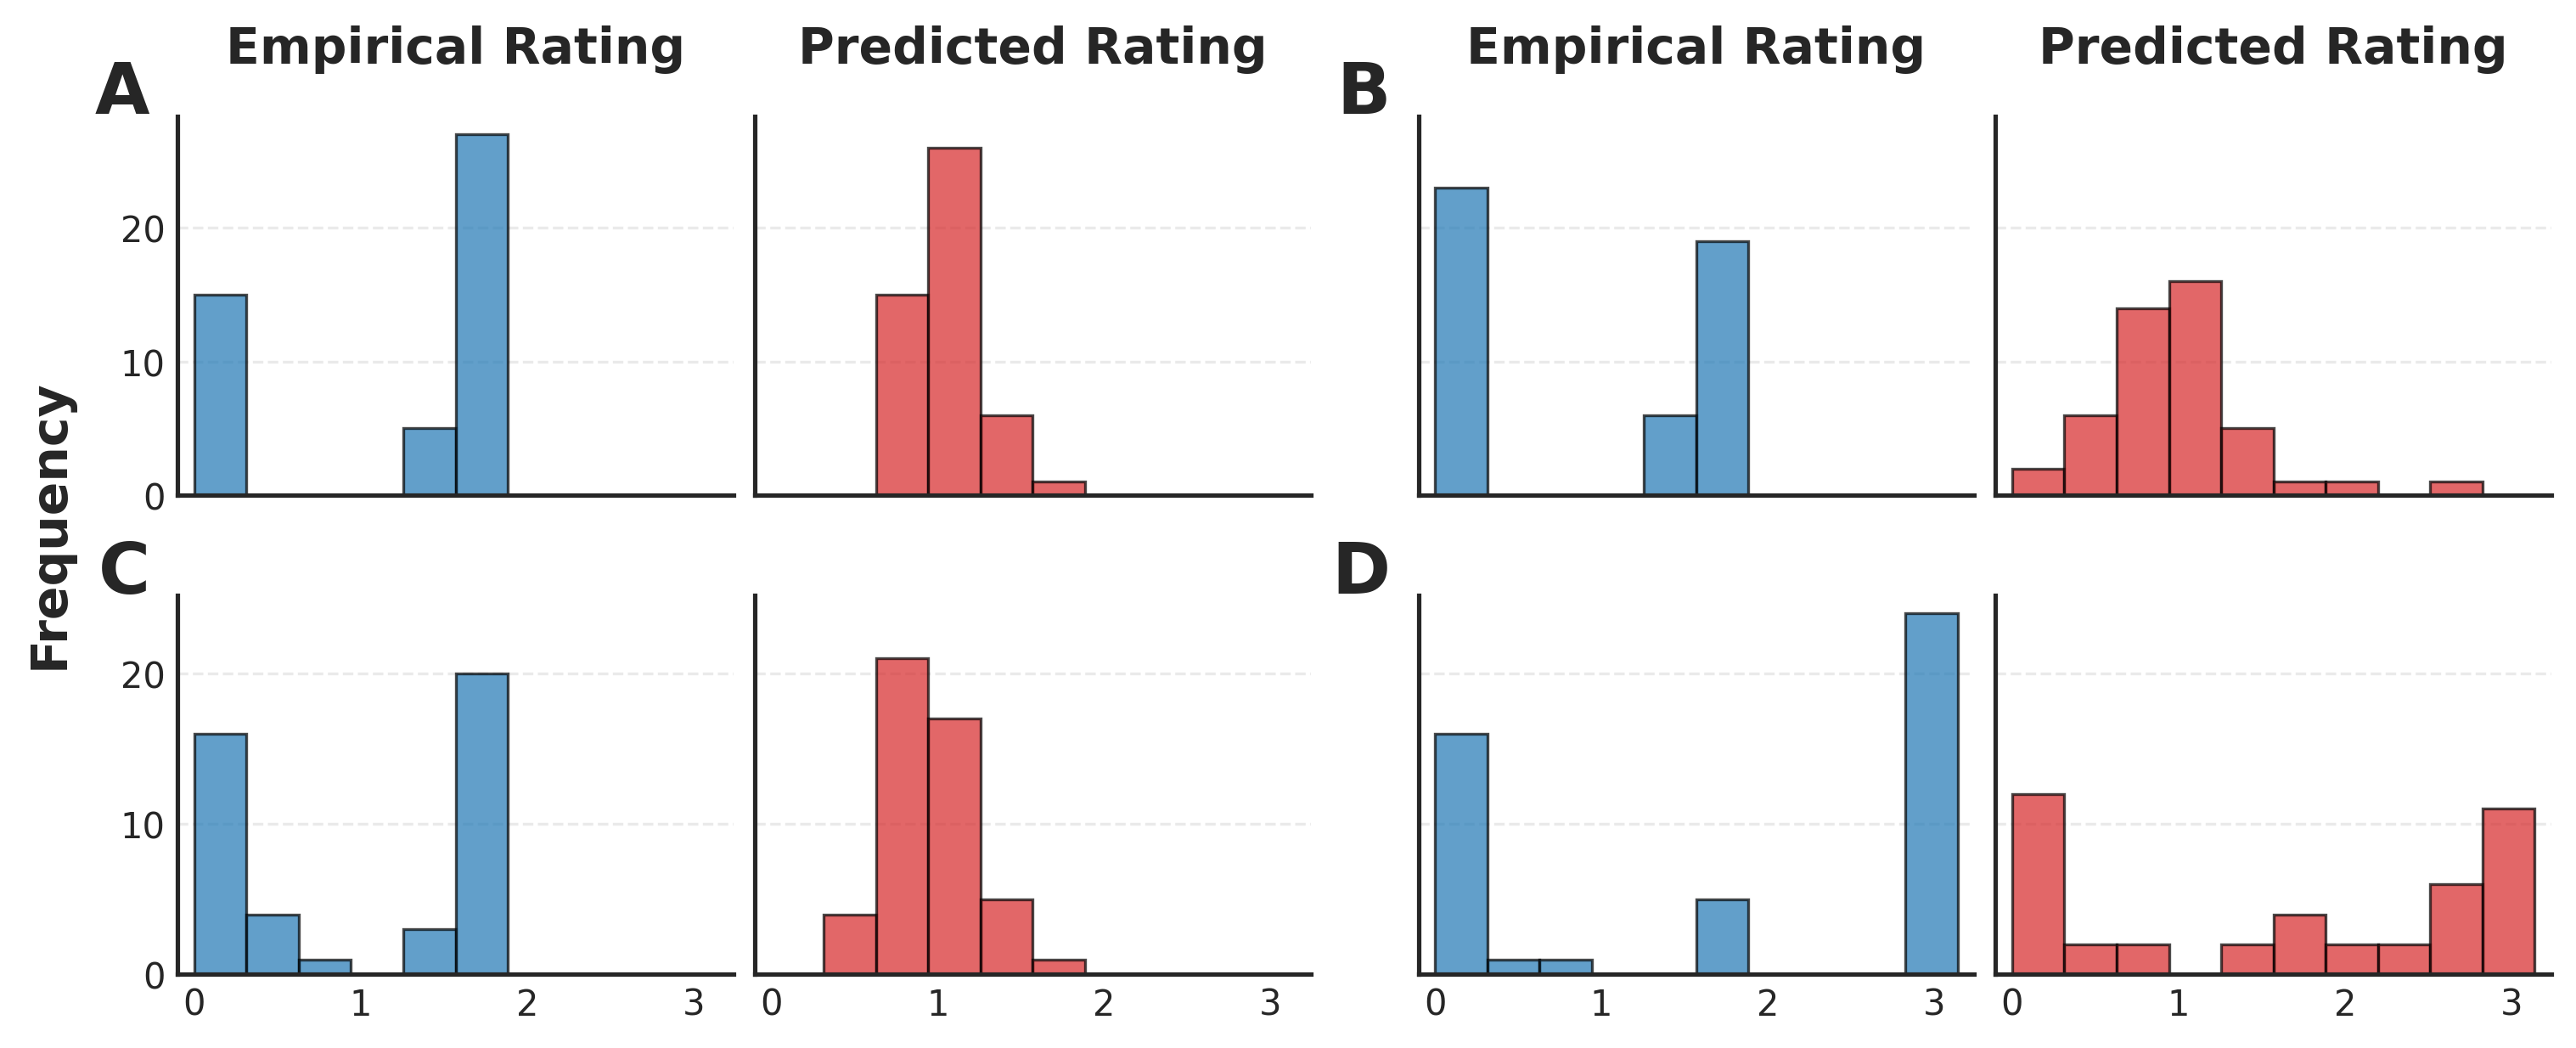

In [43]:
# Define colors and styles
empirical_color = '#1f77b4'  # Muted Blue
predicted_color = '#d62728'  # Muted Red
bin_edges = np.linspace(0, np.pi, 11)  # 10 equal bins across full range
hist_style = {'alpha': 0.7, 'edgecolor': 'black', 'linewidth': 0.8, 'bins': bin_edges}
col_titles = ["Empirical Rating", "Predicted Rating","Empirical Rating", "Predicted Rating"]

# Assuming a standard 1 to 5 rating scale
MIN_RATING = 1
MAX_RATING = 5
num_rows = 2

# 1. Setup the figure
# sharex='col', sharey='row' is still great
fig, ax = plt.subplots(num_rows, 4, figsize=(10, 2 * num_rows), dpi=300, 
                       sharex='col', sharey='row', constrained_layout=True)

# Handle the case of a single row/column, where ax is 1D
axes = ax.flatten()

for i in range(4):
    # --- User Data Logic (Simplified for example) ---
    n = problem_participant[i]
    con = problem_condition[i]
    
    # Simplified data fetch (placeholder logic)
    index = np.where(data_re["con"][n,:][:,con] == 1)
    data_resp = data_re["resp"][n,:][index]
    index_ppc = np.where(ppc_simulated["con"][n,:][:,con] == 1)
    sim_resp = ppc_simulated["resp"][n,:][index_ppc]
    
    # Column 1: Empirical Rating
    axes[2*i].hist(data_resp, color=empirical_color, **hist_style)
    axes[2*i].grid(axis='y', linestyle='--', alpha=0.4, zorder=0) # Add subtle grid
    
    # Column 2: Simulated Rating
    axes[2*i+1].hist(sim_resp, color=predicted_color, **hist_style)
    axes[2*i+1].grid(axis='y', linestyle='--', alpha=0.4, zorder=0) # Add subtle grid
    
    # --- Publication Improvements ---
    
    # 1. ADD ROW LABELS
    # axes[2*(i-1)].set_ylabel(f"P{i+1}", rotation=0, size=12, labelpad=30, 
    #                     fontweight='bold')

    axes[2*i].text(-0.05, 1.15, chr(65+i), transform=axes[2*i].transAxes,
              fontsize=20, fontweight='bold', va='top', ha='right')


    # 2. CLEAN UP SPINES
    for j in range(8):
        axes[j].spines['top'].set_visible(False)
        axes[j].spines['right'].set_visible(False)
        
    


for j, title in enumerate(col_titles):
   ax[0, j].set_title(title, fontsize=14, pad=15, fontweight='bold')

# 6. CONSISTENT X-AXIS LIMITS/TICKS
for j in range(4):
    # Set limits slightly wider than data range
    ax[-1, j].set_xlim(0-0.1, np.pi+0.1)

# 7. GLOBAL LABELS
fig.supylabel("Frequency", fontsize=14, fontweight='bold')
plt.savefig('../plots/prob_rating_bddm_2.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()